# **Clustering Capstone Notebook**  
## CDC PLACES: Community Health Equity Profiles in Illinois Census Tracts

This notebook follows the full clustering workflow from the course content:

- Problem framing
- Dataset selection
- Clustering readiness checks
- Preprocessing
- Clustering experiments
- Model validation
- Cluster interpretation
- Impact brief

## Project summary
This project uses clustering to identify meaningful groupings of Illinois census tracts (areas) using the CDC PLACES 2025 Census Tract GIS-friendly dataset. The analysis compares **K-means**, **Agglomerative clustering**, and **DBSCAN**. In the final workflow, **DBSCAN is used as a diagnostic step** to highlight extreme tracts and broad density structure, while **K-means with k = 4** is used as the final stakeholder-facing segmentation model.

Dataset: [CDC PLACES](https://www.cdc.gov/places/index.html)

## Reproducibility note
This notebook loads data directly from the CDC PLACES URL and caches a local CSV copy in the `data/` folder. Run the cells from top to bottom.

### Imports and Settings

In [75]:
# Imports and display settings
import warnings
warnings.filterwarnings("ignore")

# Standard library imports
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings for Jupyter Notebook
from IPython.display import display, Markdown

# Scikit-learn imports for preprocessing, dimensionality reduction, clustering, and evaluation
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

# Try to import scipy for hierarchical clustering and dendrogram plotting
try:
    from scipy.cluster.hierarchy import linkage, dendrogram
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Pandas display settings for better visualization of DataFrames
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", None)

# Deliverable 1: **Reflective Narrative**

### 1.1. Problem statement
Public-health planning often relies on single indicators such as diabetes prevalence, insurance access, or poor self-reported health. That can hide the fact that communities experience combinations of risks at the same time. One area/community (referenced to as *tract* in the data) may have high chronic disease burden with routine care access, while another may have moderate disease burden but weaker prevention and access.

This project uses clustering to group Illinois census tracts into health-equity profiles using the [CDC PLACES tract-level dataset](https://www.cdc.gov/places/index.html). The goal is to find patterns that can support more targeted and more equitable decisions.

### 1.2. Framing (Who, What, and Why)
This is an **unsupervised learning** problem. There is no target label to predict. The goal is to discover hidden structure across tracts and turn that structure into **actionable insights** for stakeholders.

- **Who is being grouped?**<br> Illinois census tracts.
- **What patterns are we looking for?**<br> Differences in chronic disease burden, health status, risk behaviors, prevention, and selected context measures.
- **Why does it matter?**<br> Because different tract profiles may need different public-health responses.

### 1.3. Beneficiaries and implementers

**Primary beneficiaries**
- state and local public-health departments,
- community clinics,
- nonprofit and coalition partners,
- residents in higher-burden tracts.

**Possible implementers**
- county health departments,
- community health centers,
- outreach and prevention teams,
- equity-focused funding teams.

### 1.4. Hypothesis

Expecting the analysis to reveal several meaningful profiles, including:

- Higher-burden (vulnerable group)
- Lower-burden group
- Other groups that differ in prevention, access, and chronic disease burden

### 1.5. SMART objective

- **Specific:**<br> Group Illinois census tracts using CDC PLACES indicators related to health burden, health status, prevention, and selected context measures.
- **Measurable:**<br> Compare clustering solutions using cluster quality metrics, balance, stability, and interpretability.
- **Achievable:**<br> Use a public tract-level dataset that can be loaded directly in a reproducible notebook.
- **Relevant:**<br> Support better targeting, resource allocation, and program design.
- **Time-bound:**<br> Complete the full workflow in one capstone notebook.


## 2. Dataset Selection

### 2.1. Dataset chosen
**CDC PLACES 2025 Census Tract Data — GIS-friendly format**

Soruce: [https://data.cdc.gov/api/views/yjkw-uj5s/rows.csv?accessType=DOWNLOAD](https://data.cdc.gov/api/views/yjkw-uj5s/rows.csv?accessType=DOWNLOAD) for the CSV file

### 2.2. Project fit

This dataset is a strong fit for the problem because it supports tract-level (specific areas) public-health profiling with a broad set of data points that can be used to compare chronic disease burden, health status, prevention behavior, and selected community-related indicators in one consistent table.

- The data are available from a public URL, which supports notebook reproducibility.
- The file includes tract identifiers and tract-level prevalence fields, which match the analysis unit used in the project.
- After filtering to Illinois, the working dataset contains over 3,000 census tracts, which is large enough to support a meaningful clustering exercise.
- The selected analytical features are numeric which makes them appropriate for distance-based clustering after scaling.
- The dataset is broad enough to support statewide pattern discovery and stakeholder interpretation.

Sample County information (dedicated web page): [Cook County, Illinois](https://data.census.gov/profile/Cook_County,_Illinois?g=050XX00US17031#health)

### 2.3. Ethical and practical considerations

- **Beneficiary relevance:**<br> The data can support planning for health departments, public/private clinics, nonprofit organizations, and funders for programs.
- **Representativeness:**<br> The tract-level (area) granularity provides broad statewide coverage rather than a small convenience sample.
- **Ethics and privacy:**<br> The analysis uses public, aggregated tract-level estimates rather than individual records.
- **Practical suitability:**<br> The file is already structured for analysis and can be loaded directly in the notebook.
- **Method fit:**<br> The dataset contains enough variation to support pattern discovery across tracts.

### 2.4. Important limitation
This dataset is best used as a screening and targeting tool since it is based on a limited set of historical information. Therefore, it should not replace local knowledge, expert opinions, or be used to label communities in a harmful way.

In [76]:
# Directory setup for data, outputs, plots, and tables

# Determine project root and set up directories for data, outputs, plots, and tables
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD       # Assumes this notebook is in a "notebooks" folder
DATA_DIR = PROJECT_ROOT / "data"                                            # Directory for raw and processed data files
OUTPUT_DIR = PROJECT_ROOT / "outputs"                                       # Directory for all generated outputs, including plots and tables
PLOTS_DIR = OUTPUT_DIR / "plots"                                            # Directory for saving generated plots
TABLES_DIR = OUTPUT_DIR / "tables"                                          # Directory for saving generated tables

# Create necessary directories if they don't exist
for folder in [DATA_DIR, OUTPUT_DIR, PLOTS_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Constants for CDC PLACES dataset URL and local CSV file candidates (preferred and alternative filenames and locations since several versions are used during development and testing)
CDC_PLACES_URL = "https://data.cdc.gov/api/views/yjkw-uj5s/rows.csv?accessType=DOWNLOAD"
LOCAL_CSV_CANDIDATES = [
    DATA_DIR / "cdc_places_tract_2025.csv",                                                 # Preferred local filename
    DATA_DIR / "PLACES__Census_Tract_Data__GIS_Friendly_Format___2025_release.csv",         # Alternative local filename that might be used if the preferred one is not found
    PROJECT_ROOT / "PLACES__Census_Tract_Data__GIS_Friendly_Format___2025_release.csv",     # Alternative location at the project root in case the data was placed there instead of in the data/ folder   
]
LOCAL_CSV = LOCAL_CSV_CANDIDATES[0]                                                         # The primary local CSV file path to save the downloaded dataset for future use

# Function: slugify
# Utility functions for slugifying names, saving figures and tables, and loading the CDC PLACES dataset
def slugify(value):
    value = re.sub(r"[^A-Za-z0-9]+", "_", str(value)).strip("_").lower()
    return value or "artifact"

# Function: save_fig
# Saves a matplotlib figure with a slugified name in the plots directory
def save_fig(name, fig=None, dpi=300):
    fig = fig if fig is not None else plt.gcf()
    path = PLOTS_DIR / f"{slugify(name)}.png"
    fig.savefig(path, bbox_inches="tight", dpi=dpi)
    return path

# Function: save_table
# Saves a DataFrame as a CSV file with a slugified name in the tables directory
def save_table(df_to_save, name, index=True):
    path = TABLES_DIR / f"{slugify(name)}.csv"
    df_to_save.to_csv(path, index=index)
    return path

# Function: show_table
# Displays a DataFrame and saves it as a CSV file with a slugified name in the tables directory
def show_table(df_to_show, name, index=True, preview=None):
    path = save_table(df_to_show, name, index=index)
    display(df_to_show if preview is None else preview)
    print(f"Saved table: {path.relative_to(PROJECT_ROOT)}")
    return path

# Function: load_places_data
# Loads the CDC PLACES dataset from a local file if available, otherwise downloads it from the specified URL and saves a local copy for future use.
def load_places_data(url=CDC_PLACES_URL, local_candidates=None, force_download=False):
    local_candidates = local_candidates or LOCAL_CSV_CANDIDATES

    if not force_download:
        for candidate in local_candidates:
            if candidate.exists():
                print(f"Loading local file: {candidate}")
                df_loaded = pd.read_csv(candidate, low_memory=False)
                return df_loaded

    print("Downloading CDC PLACES dataset...")
    try:
        df_loaded = pd.read_csv(url, low_memory=False)
    except Exception as exc:
        raise RuntimeError(
            "The CDC PLACES file could not be downloaded. "
            "Place the CSV in the data/ folder and rerun the notebook."
        ) from exc

    df_loaded.to_csv(LOCAL_CSV, index=False)
    print(f"Saved local copy to: {LOCAL_CSV}")
    return df_loaded

# Load the CDC PLACES dataset, clean column names, and display the first few rows along with available measure inventory
df_raw = load_places_data()
df_raw.columns = pd.Index([str(c).strip() for c in df_raw.columns])

# 
print("Raw shape:", df_raw.shape)
display(df_raw.head())

# Extract available measure stems from column names and create a DataFrame to display the inventory of measures
available_prev_cols = [c for c in df_raw.columns if re.search(r"_(AgeAdjPrev|CrudePrev)$", c)]
available_stems = sorted({re.sub(r"_(AgeAdjPrev|CrudePrev)$", "", c) for c in available_prev_cols})
available_inventory_df = pd.DataFrame({"available_measure_stem": available_stems})

show_table(available_inventory_df, "available_measure_inventory", index=False, preview=available_inventory_df.head(20))


Loading local file: /workspaces/ToU-Clustering/data/cdc_places_tract_2025.csv
Raw shape: (83522, 88)


,StateAbbr,StateDesc,CountyName,CountyFIPS,TractFIPS,TotalPopulation,TotalPop18plus,ACCESS2_CrudePrev,ACCESS2_Crude95CI,ARTHRITIS_CrudePrev,ARTHRITIS_Crude95CI,BINGE_CrudePrev,BINGE_Crude95CI,BPHIGH_CrudePrev,BPHIGH_Crude95CI,BPMED_CrudePrev,BPMED_Crude95CI,CANCER_CrudePrev,CANCER_Crude95CI,CASTHMA_CrudePrev,CASTHMA_Crude95CI,CHD_CrudePrev,CHD_Crude95CI,CHECKUP_CrudePrev,CHECKUP_Crude95CI,CHOLSCREEN_CrudePrev,CHOLSCREEN_Crude95CI,COLON_SCREEN_CrudePrev,COLON_SCREEN_Crude95CI,COPD_CrudePrev,COPD_Crude95CI,CSMOKING_CrudePrev,CSMOKING_Crude95CI,DENTAL_CrudePrev,DENTAL_Crude95CI,DEPRESSION_CrudePrev,DEPRESSION_Crude95CI,DIABETES_CrudePrev,DIABETES_Crude95CI,GHLTH_CrudePrev,GHLTH_Crude95CI,HIGHCHOL_CrudePrev,HIGHCHOL_Crude95CI,LPA_CrudePrev,LPA_Crude95CI,MAMMOUSE_CrudePrev,MAMMOUSE_Crude95CI,MHLTH_CrudePrev,MHLTH_Crude95CI,OBESITY_CrudePrev,OBESITY_Crude95CI,PHLTH_CrudePrev,PHLTH_Crude95CI,SLEEP_CrudePrev,SLEEP_Crude95CI,STROKE_CrudePrev,STROKE_Crude95CI,TEETHLOST_CrudePrev,TEETHLOST_Crude95CI,HEARING_CrudePrev,HEARING_Crude95CI,VISION_CrudePrev,VISION_Crude95CI,COGNITION_CrudePrev,COGNITION_Crude95CI,MOBILITY_CrudePrev,MOBILITY_Crude95CI,SELFCARE_CrudePrev,SELFCARE_Crude95CI,INDEPLIVE_CrudePrev,INDEPLIVE_Crude95CI,DISABILITY_CrudePrev,DISABILITY_Crude95CI,LONELINESS_CrudePrev,LONELINESS_Crude95CI,FOODSTAMP_CrudePrev,FOODSTAMP_Crude95CI,FOODINSECU_CrudePrev,FOODINSECU_Crude95CI,HOUSINSECU_CrudePrev,HOUSINSECU_Crude95CI,SHUTUTILITY_CrudePrev,SHUTUTILITY_Crude95CI,LACKTRPT_CrudePrev,LACKTRPT_Crude95CI,EMOTIONSPT_CrudePrev,EMOTIONSPT_Crude95CI,Geolocation
0,AL,Alabama,Autauga,1001,1001020100,1775,1370,9.7,"( 7.4, 12.3)",30.6,"(27.2, 34.0)",14.8,"(12.1, 17.7)",41.4,"(37.1, 45.7)",77.8,"(74.9, 80.4)",8.5,"( 7.6, 9.4)",10.2,"( 9.0, 11.6)",7.2,"( 6.2, 8.1)",80.1,"(76.6, 83.3)",85.5,"(82.9, 87.8)",65.0,"(59.8, 70.2)",8.2,"( 6.8, 9.8)",15.6,"(12.6, 18.9)",57.3,"(53.2, 61.2)",26.6,"(22.7, 30.5)",13.3,"(11.4, 15.3)",22.5,"(18.8, 26.4)",41.9,"(37.4, 46.2)",27.8,"(22.7, 32.9)",78.0,"(70.8, 84.4)",17.9,"(15.5, 20.4)",39.4,"(31.9, 47.2)",14.7,"(12.5, 16.8)",37.9,"(31.6, 44.4)",3.8,"( 3.3, 4.3)",13.4,"(11.0, 16.3)",8.6,"( 7.4, 9.7)",5.5,"( 4.8, 6.4)",16.8,"(14.1, 19.5)",16.3,"(13.7, 18.9)",4.4,"( 3.7, 5.1)",9.6,"( 8.1, 11.2)",35.7,"(30.4, 40.8)",33.0,"(28.2, 38.3)",11.6,"( 9.2, 14.4)",17.0,"(13.8, 20.9)",12.3,"(10.2, 14.7)",8.1,"( 6.9, 9.6)",8.9,"( 7.5, 10.4)",23.5,"(19.9, 27.4)",POINT (-86.4915648 32.4819731)
1,AL,Alabama,Autauga,1001,1001020200,2055,1584,10.6,"( 8.5, 13.0)",29.5,"(26.0, 32.7)",12.9,"(10.4, 15.4)",45.9,"(41.5, 50.1)",78.3,"(75.6, 80.7)",6.3,"( 5.7, 7.0)",10.8,"( 9.5, 12.2)",6.5,"( 5.8, 7.3)",81.8,"(78.5, 84.7)",85.6,"(83.4, 87.5)",68.1,"(63.4, 72.7)",7.6,"( 6.5, 8.7)",16.7,"(13.9, 19.5)",56.1,"(52.2, 60.2)",23.3,"(19.8, 26.9)",15.8,"(13.7, 18.0)",25.1,"(21.7, 28.7)",39.7,"(35.4, 44.1)",32.0,"(26.9, 37.3)",79.2,"(72.4, 85.1)",18.5,"(16.2, 20.7)",44.7,"(36.6, 52.3)",14.4,"(12.5, 16.3)",42.6,"(36.0, 49.4)",4.4,"( 3.9, 4.8)",15.9,"(12.9, 19.4)",6.7,"( 5.9, 7.6)",6.6,"( 5.8, 7.4)",17.3,"(15.0, 19.7)",17.8,"(15.4, 20.2)",5.0,"( 4.4, 5.7)",10.4,"( 9.1, 11.9)",36.9,"(32.0, 41.8)",36.1,"(31.2, 41.6)",18.4,"(15.0, 22.1)",24.8,"(20.9, 29.1)",18.5,"(15.6, 21.6)",12.5,"(10.7, 14.4)",12.0,"(10.3, 13.8)",29.1,"(25.2, 33.6)",POINT (-86.4724678 32.475758)
2,AL,Alabama,Autauga,1001,1001020300,3216,2485,10.6,"( 8.4, 13.1)",31.5,"(28.2, 34.8)",13.9,"(11.3, 16.8)",42.9,"(38.7, 47.0)",78.4,"(75.7, 80.7)",8.5,"( 7.6, 9.4)",10.7,"( 9.4, 12.1)",7.3,"( 6.3, 8.2)",80.6,"(77.0, 83.7)",85.5,"(83.0, 87.6)",67.4,"(62.2, 72.4)",8.5,"( 7.3, 9.9)",16.1,"(13.5, 18.8)",57.7,"(53.7, 61.7)",26.3,"(22.6, 30.2)",13.9,"(12.0, 15.9)",23.7,"(20.4, 27.3)",41.8,"(37.6, 46.1)",29.9,"(24.9, 34.8)",75.5,"(67.9, 82.3)",18.6,"(16.3, 20.8)",40.3,"(32.7, 47.7)",15.1,"(13.2, 17.2)",39.0,"(32.6, 45.7)",4.1,"( 3.7, 4.6)",14.7,"(12.0, 17.7)",8.6,"( 7.6, 9.7)",5.8,"( 5.1, 6.6)",17.6,"(15.2, 20.0)",17.6,"(15.1, 20.1)",4.6,"( 4.0, 5.2)",10.3,"( 8.9, 11.8)",37.7,"(32.8, 42.4)",35.1,"(30.0

,available_measure_stem
0,ACCESS2
1,ARTHRITIS
2,BINGE
3,BPHIGH
4,BPMED
5,CANCER
6,CASTHMA
7,CHD
8,CHECKUP
9,CHOLSCREEN


Saved table: outputs/tables/available_measure_inventory.csv


PosixPath('/workspaces/ToU-Clustering/outputs/tables/available_measure_inventory.csv')

**🕵️‍♂️ Interpretation/Notes:**<br>
- The raw CDC PLACES file contains 83,522 rows and 88 columns.
- The dataset is now cached locally so the notebook can be rerun more easily.
- Plots will be saved to outputs/plots and tables will be saved to outputs/tables.

## 3. Scope Choice and Analysis Unit

This notebook uses **Illinois census tracts** as the main unit for comparison.

Note:<br>
The state filter can be changed to another state. 

In [77]:
# Filter to Illinois tracts for the main analysis
STATE_COLUMN = "StateAbbr"
STATE_VALUE = "IL"

# Check if the expected state abbreviation column is present before filtering, and raise an error with guidance if it's not found (to handle potential changes in the dataset structure by CDC)
if STATE_COLUMN not in df_raw.columns:
    raise KeyError(
        f"Expected geography column '{STATE_COLUMN}' was not found. "
        "Inspect df_raw.columns and update this notebook if CDC changes the export."
    )

# Filter the dataset to include only rows where the state abbreviation matches the specified value (Illinois in this case) and create a copy of the filtered DataFrame for further analysis.
df = df_raw[df_raw[STATE_COLUMN] == STATE_VALUE].copy()

# Select a subset of columns to display for sanity checking the filtered dataset.
display_cols = [c for c in [
    "StateAbbr", "StateDesc", "CountyName", "TractFIPS", "TotalPopulation", "TotalPop18plus"
] if c in df.columns]

# Display the shape of the filtered dataset and the first few rows of the selected columns to verify that the filtering worked as expected.
print("Filtered dataset shape:", df.shape)
display(df[display_cols].head())

# Show the number of tracts per county for the top 20 counties in Illinois, and save this information as a table.
print("Number of tracts per county (top 20):")
if "CountyName" in df.columns:
    county_counts = df["CountyName"].value_counts().head(20).to_frame("tract_count")
    show_table(county_counts, "illinois_top_20_county_tract_counts", index=True)

Filtered dataset shape: (3258, 88)


,StateAbbr,StateDesc,CountyName,TractFIPS,TotalPopulation,TotalPop18plus
24755,IL,Illinois,Adams,17001000100,4644,3762
24756,IL,Illinois,Adams,17001000201,2067,1626
24757,IL,Illinois,Adams,17001000202,2870,2301
24758,IL,Illinois,Adams,17001000400,3793,2932
24759,IL,Illinois,Adams,17001000500,1719,1358


Number of tracts per county (top 20):


,tract_count
CountyName,
Cook,1328
DuPage,219
Will,171
Lake,159
Kane,104
Winnebago,79
St. Clair,68
McHenry,64
Madison,63


Saved table: outputs/tables/illinois_top_20_county_tract_counts.csv


**🕵️‍♂️ Interpretation/Notes:**<br>
- After filtering, the main analysis dataset contains **3,258 Illinois census tracts**.
- A quick spot check against the CDC PLACES source suggests that the downloaded data match the published values.
- This is a large enough tract sample for clustering and supports a statewide segmentation exercise.

## 4. Feature Selection

### 4.1. Features


The feature set is designed to cover the main parts of the problem:

1. Chronic disease burden
2. Health status
3. Prevention and access
4. Risk behaviors

And small number of context indicators. The goal is to keep the model broad enough to be meaningful, but focused enough to stay interpretable.

In [78]:
# Build the feature map from columns that are actually present in the dataset
planned_feature_concepts = [
    ("core_health", "insurance_or_access", ["ACCESS2"]),                            #  1. Access to health care / insurance coverage
    ("core_health", "routine_checkup", ["CHECKUP"]),                                #  2. Routine medical checkups
    ("core_health", "high_blood_pressure", ["BPHIGH"]),                             #  3. High blood pressure prevalence
    ("core_health", "asthma", ["CASTHMA"]),                                         #  4. Asthma prevalence         
    ("core_health", "coronary_heart_disease", ["CHD"]),                             #  5. Coronary heart disease prevalence
    ("core_health", "copd", ["COPD"]),                                              #  6. Chronic obstructive pulmonary disease prevalence
    ("core_health", "diabetes", ["DIABETES"]),                                      #  7. Diabetes prevalence
    ("core_health", "smoking", ["CSMOKING"]),                                       #  8. Smoking prevalence
    ("core_health", "physical_inactivity", ["LPA"]),                                #  9. Physical inactivity prevalence
    ("core_health", "obesity", ["OBESITY"]),                                        # 10. Obesity prevalence
    ("core_health", "poor_mental_health", ["MHLTH"]),                               # 11. Poor mental health prevalence
    ("core_health", "poor_physical_health", ["PHLTH"]),                             # 12. Poor physical health prevalence  
    ("core_health", "fair_or_poor_general_health", ["GHLTH"]),                      # 13. Fair or poor general health prevalence  
    ("core_health", "insufficient_sleep", ["SLEEP"]),                               # 14. Insufficient sleep prevalence
    ("core_health", "stroke", ["STROKE"]),                                          # 15. Stroke prevalence      
    ("core_health", "teeth_lost", ["TEETHLOST"]),                                   # 16. Prevalence of adults who have lost all their natural teeth
    ("context", "food_or_material_stress", ["FOODSTAMP", "FOODINSECU"]),            # 17. Food or material hardship prevalence
    ("context", "housing_or_utility_stress", ["HOUSINSECU", "SHUTUTILITY"]),        # 18. Housing or utility hardship prevalence
    ("context", "transport_barrier", ["LACKTRPT"]),                                 # 19. Transportation barrier prevalence
    ("context", "social_support", ["EMOTIONSPT", "LONELINESS"]),                    # 20. Social support / loneliness prevalence
]

# This function checks the dataset columns for the presence of candidate measure columns based on the planned feature concepts.
def choose_measure_col(columns, candidate_stems):
    for stem in candidate_stems:
        for suffix in ["AgeAdjPrev", "CrudePrev"]:
            candidate = f"{stem}_{suffix}"
            if candidate in columns:
                return candidate, stem, suffix
    return None, None, None

# Build a feature map that links the planned concepts to actual columns in the dataset, so later cells can refer to this map instead of assuming certain fields exist.
feature_records = []
for feature_group, concept, candidate_stems in planned_feature_concepts:
    selected_col, matched_stem, selected_suffix = choose_measure_col(df.columns, candidate_stems)
    feature_records.append({
        "feature_group": feature_group,                                             # Grouping for later analysis or interpretation
        "concept": concept,                                                         # Planned feature concept being mapped  
        "candidate_stems": ", ".join(candidate_stems),                              # Candidate column stems considered for this concept
        "selected_stem": matched_stem,                                              # The stem of the column that was actually found in the dataset (or None if not found)
        "selected_measure_type": selected_suffix,                                   # The measure type suffix of the column that was found (e.g., AgeAdjPrev or CrudePrev), or None if not found
        "selected_column": selected_col,                                            # The actual column name that was found in the dataset for this concept, or None if not found
        "available": selected_col is not None                                       # Whether a usable column was found for this concept in the dataset
    })

# Create a DataFrame from the feature map and display it, along with an interpretation of how many planned concepts have usable columns in the dataset.
feature_map_df = pd.DataFrame(feature_records)
show_table(feature_map_df, "feature_mapping_table", index=False)

# Count how many planned feature concepts have usable columns in the dataset and identify any concepts that could not be mapped to a column.
available_count = int(feature_map_df["available"].sum())
missing_concepts = feature_map_df.loc[~feature_map_df["available"], "concept"].tolist()

,feature_group,concept,candidate_stems,selected_stem,selected_measure_type,selected_column,available
0,core_health,insurance_or_access,ACCESS2,ACCESS2,CrudePrev,ACCESS2_CrudePrev,True
1,core_health,routine_checkup,CHECKUP,CHECKUP,CrudePrev,CHECKUP_CrudePrev,True
2,core_health,high_blood_pressure,BPHIGH,BPHIGH,CrudePrev,BPHIGH_CrudePrev,True
3,core_health,asthma,CASTHMA,CASTHMA,CrudePrev,CASTHMA_CrudePrev,True
4,core_health,coronary_heart_disease,CHD,CHD,CrudePrev,CHD_CrudePrev,True
5,core_health,copd,COPD,COPD,CrudePrev,COPD_CrudePrev,True
6,core_health,diabetes,DIABETES,DIABETES,CrudePrev,DIABETES_CrudePrev,True
7,core_health,smoking,CSMOKING,CSMOKING,CrudePrev,CSMOKING_CrudePrev,True
8,core_health,physical_inactivity,LPA,LPA,CrudePrev,LPA_CrudePrev,True
9,core_health,obesity,OBESITY,OBESITY,CrudePrev,OBESITY_CrudePrev,True


Saved table: outputs/tables/feature_mapping_table.csv


**🕵️‍♂️ Interpretation/Notes:**<br>
- The feature map checks 20 planned concepts and finds 20 usable columns in this CDC release.

In [79]:
# Final feature list derived from the available feature map.
feature_cols = (
    feature_map_df.loc[feature_map_df["available"], "selected_column"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

# Filter the final feature list to only include columns that exist in the dataset and are numeric, since clustering algorithms require numeric input.
feature_cols = [c for c in feature_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]

# Create a rationale table that explains which planned concepts were mapped to which actual columns in the dataset, and an inventory table that lists the final selected features along with their measure types.
feature_selection_rationale_df = feature_map_df.loc[
    feature_map_df["selected_column"].isin(feature_cols),
    ["feature_group", "concept", "selected_stem", "selected_column"]
].copy()

# The inventory table includes the measure stem and measure type for each selected feature, which can be useful for later interpretation or analysis of the features.
feature_inventory_df = pd.DataFrame({
    "selected_column": feature_cols,
    "measure_stem": [re.sub(r"_(AgeAdjPrev|CrudePrev)$", "", c) for c in feature_cols],
    "measure_type": [re.search(r"(AgeAdjPrev|CrudePrev)$", c).group(1) if re.search(r"(AgeAdjPrev|CrudePrev)$", c) else "other" for c in feature_cols]
})

# Ensure that we have a sufficient number of features to proceed with clustering, and display the selected features along with the rationale for their selection (assuming 8).
if len(feature_cols) < 8:
    raise ValueError(
        f"Only {len(feature_cols)} usable numeric features were found. "
        "Review the dataset columns and update the feature plan if the CDC export changed."
    )

# Display the selected numeric features and the rationale for their selection, along with an interpretation that explains how the final feature set was determined based on the available columns in the dataset.
print(f"Selected numeric features: {len(feature_cols)}")
show_table(feature_selection_rationale_df, "selected_feature_mapping", index=False)
show_table(feature_inventory_df, "selected_feature_inventory", index=False)


Selected numeric features: 20


,feature_group,concept,selected_stem,selected_column
0,core_health,insurance_or_access,ACCESS2,ACCESS2_CrudePrev
1,core_health,routine_checkup,CHECKUP,CHECKUP_CrudePrev
2,core_health,high_blood_pressure,BPHIGH,BPHIGH_CrudePrev
3,core_health,asthma,CASTHMA,CASTHMA_CrudePrev
4,core_health,coronary_heart_disease,CHD,CHD_CrudePrev
5,core_health,copd,COPD,COPD_CrudePrev
6,core_health,diabetes,DIABETES,DIABETES_CrudePrev
7,core_health,smoking,CSMOKING,CSMOKING_CrudePrev
8,core_health,physical_inactivity,LPA,LPA_CrudePrev
9,core_health,obesity,OBESITY,OBESITY_CrudePrev


Saved table: outputs/tables/selected_feature_mapping.csv


,selected_column,measure_stem,measure_type
0,ACCESS2_CrudePrev,ACCESS2,CrudePrev
1,CHECKUP_CrudePrev,CHECKUP,CrudePrev
2,BPHIGH_CrudePrev,BPHIGH,CrudePrev
3,CASTHMA_CrudePrev,CASTHMA,CrudePrev
4,CHD_CrudePrev,CHD,CrudePrev
5,COPD_CrudePrev,COPD,CrudePrev
6,DIABETES_CrudePrev,DIABETES,CrudePrev
7,CSMOKING_CrudePrev,CSMOKING,CrudePrev
8,LPA_CrudePrev,LPA,CrudePrev
9,OBESITY_CrudePrev,OBESITY,CrudePrev


Saved table: outputs/tables/selected_feature_inventory.csv


PosixPath('/workspaces/ToU-Clustering/outputs/tables/selected_feature_inventory.csv')

**🕵️‍♂️ Interpretation/Notes:**<br>
- The working feature set contains 20 numeric variables.
- Only columns that are both present and numeric are kept in the final analytical feature list (all in this case).

### 4.2. Feature-selection rationale

The selected concepts were chosen because they reflect the main dimensions of the problem statement: disease burden, health status, prevention and access, risk behaviors, and a small number of context indicators. In this tract extract, the most consistently available fields for the chosen concepts were crude prevalence measures, so those were used to preserve broad coverage across all tracts.

## 5. Dataset Exploration and Quality Review

Initial profiling of the dataset, including counting numeric columns, missing values, and duplicates, and save this information as tables for reference.

### 5.1. EDA

This section reviews the dataset before clustering. The things checked include:

1. Data size and types
2. Missingness
3. Duplications

In [80]:
# Count all numeric columns in the dataset, which gives an idea of how many potential features are available before filtering down to the selected feature set for clustering.
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()

# Create a profiling table that summarizes the dataset columns, including their data types, counts of missing values, and percentages of missing values, sorted by the percentage of missing values in descending order and then by column name in ascending order for easier identification of columns with high missingness.
profile_table = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
}).sort_values(["missing_pct", "column"], ascending=[False, True])

# Count duplicate rows in the dataset, as well as duplicate tract identifiers if the "TractFIPS" column exists, which can indicate potential data quality issues that may need to be addressed before clustering.
duplicate_rows = int(df.duplicated().sum())
duplicate_tracts = int(df["TractFIPS"].duplicated().sum()) if "TractFIPS" in df.columns else None

print("Dataset shape:", df.shape)
print("Numeric columns:", len(numeric_cols_all))
print("Selected analytical features:", len(feature_cols))
print("Duplicate rows:", duplicate_rows)
print("Duplicate TractFIPS:", duplicate_tracts)

show_table(profile_table.head(30), "profile_table_top_30", index=False)
profile_summary = pd.DataFrame({
    "metric": ["row_count", "column_count", "numeric_column_count", "selected_feature_count", "duplicate_rows", "duplicate_tract_ids"],
    "value": [df.shape[0], df.shape[1], len(numeric_cols_all), len(feature_cols), duplicate_rows, duplicate_tracts]
})
show_table(profile_summary, "dataset_profile_summary", index=False)

Dataset shape: (3258, 88)
Numeric columns: 44
Selected analytical features: 20
Duplicate rows: 0
Duplicate TractFIPS: 0


,column,dtype,missing_count,missing_pct
58,TEETHLOST_Crude95CI,str,1,0.03
57,TEETHLOST_CrudePrev,float64,1,0.03
8,ACCESS2_Crude95CI,str,0,0.00
7,ACCESS2_CrudePrev,float64,0,0.00
10,ARTHRITIS_Crude95CI,str,0,0.00
9,ARTHRITIS_CrudePrev,float64,0,0.00
12,BINGE_Crude95CI,str,0,0.00
11,BINGE_CrudePrev,float64,0,0.00
14,BPHIGH_Crude95CI,str,0,0.00
13,BPHIGH_CrudePrev,float64,0,0.00


Saved table: outputs/tables/profile_table_top_30.csv


,metric,value
0,row_count,3258
1,column_count,88
2,numeric_column_count,44
3,selected_feature_count,20
4,duplicate_rows,0
5,duplicate_tract_ids,0


Saved table: outputs/tables/dataset_profile_summary.csv


PosixPath('/workspaces/ToU-Clustering/outputs/tables/dataset_profile_summary.csv')

**🕵️‍♂️ Interpretation/Notes:**<br>
- The Illinois subset includes 3,258 rows and 88 columns.
- No duplicates detected rows or IDs.
- Missing values are negligible (not worth handling).

### 5.2. Visualize Missingness

Given that we can't assume that all states will have little to no missing values (as opposed to Illinois), the following cell visualizes missing values and maps it to percentages:

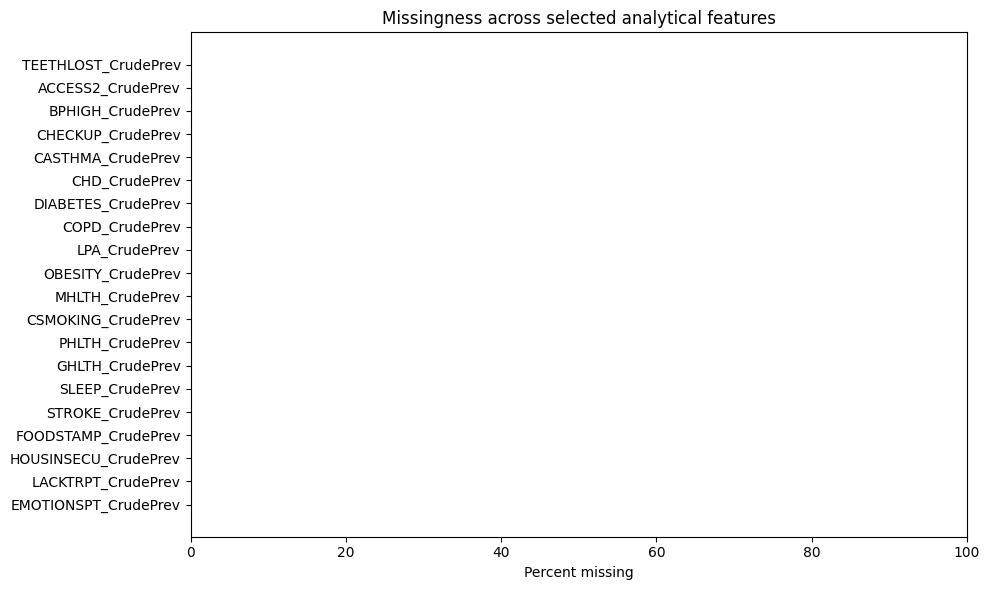

,missing_pct
TEETHLOST_CrudePrev,0.030694
ACCESS2_CrudePrev,0.000000
BPHIGH_CrudePrev,0.000000
CHECKUP_CrudePrev,0.000000
CASTHMA_CrudePrev,0.000000
CHD_CrudePrev,0.000000
DIABETES_CrudePrev,0.000000
COPD_CrudePrev,0.000000
LPA_CrudePrev,0.000000
OBESITY_CrudePrev,0.000000


Saved table: outputs/tables/feature_missingness_percent.csv


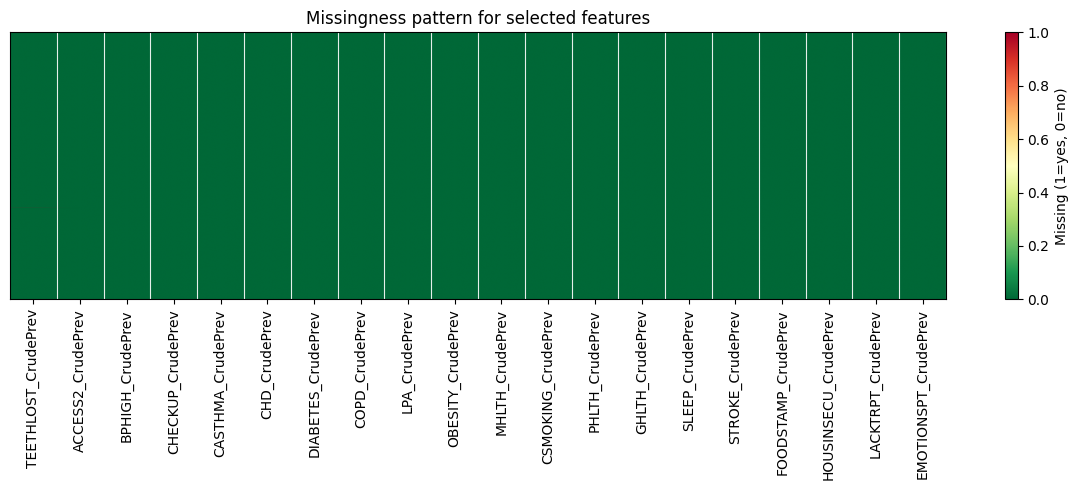

In [81]:
# Visualize missingness across the selected analytical features
feature_missing_pct = (df[feature_cols].isna().mean() * 100).sort_values(ascending=False)

# Create a horizontal bar plot to show the percentage of missing values for each selected feature, sorted from highest to lowest missingness. This helps identify if any features have a high rate of missing data that might require special handling.
plt.figure(figsize=(10, 6))
plt.barh(feature_missing_pct.index[::-1], feature_missing_pct.values[::-1], edgecolor="white", linewidth=0.8)
plt.xlabel("Percent missing")
plt.xlim(0, 100)
plt.title("Missingness across selected analytical features")
plt.tight_layout()
save_fig("missingness_across_selected_features")
plt.show()

# Display a table showing the percentage of missing values for each selected feature so that the missingness can be reviewed in tabular form as well as visually.
show_table(feature_missing_pct.to_frame("missing_pct"), "feature_missingness_percent", index=True)

# Visualize the missingness pattern across the top features with the highest missing rates, up to a maximum of 20 features, to see if there are any patterns in which tracts are missing data for which features.
top_missing_features = feature_missing_pct.head(min(20, len(feature_missing_pct))).index.tolist()

# If there are any features with missing data, create a heatmap to visualize the missingness pattern across the tracts for those features. This can help identify if certain tracts are missing data for multiple features or if the missingness is random.
if top_missing_features:
    plt.figure(figsize=(12, 5))
    im = plt.imshow(df[top_missing_features].isna().astype(int), aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=1)
    plt.colorbar(im, label="Missing (1=yes, 0=no)")
    plt.yticks([])
    plt.xticks(range(len(top_missing_features)), top_missing_features, rotation=90)

    # Adding white divider lines between feature columns for readability.
    for x in np.arange(0.5, len(top_missing_features), 1):
        plt.axvline(x=x, color="white", linewidth=0.8, alpha=0.9)

    plt.title("Missingness pattern for selected features")
    plt.tight_layout()
    save_fig("missingness_pattern_selected_features")
    plt.show()

**🕵️‍♂️ Interpretation/Notes:**<br>
- Missingness is very low (negligible) across the selected features. The highest missing rate is 0.03%.
- This means missing-data handling is unlikely to drive the final result.

### 5.3. Summary Statistics

In [82]:
# Summary statistics and skewness for analytical features
feature_summary = df[feature_cols].describe().T
feature_summary["missing_pct"] = df[feature_cols].isna().mean() * 100
feature_summary["skew"] = df[feature_cols].skew(numeric_only=True)

# Display a table showing the summary statistics, missingness percentage, and skewness for each selected analytical feature, sorted by missingness percentage in descending order so that features with more missing data are reviewed first.
show_table(feature_summary.sort_values("missing_pct", ascending=False), "feature_summary_statistics", index=True)

# Identify the three most skewed features based on absolute skewness values so that any features with extreme asymmetry in their distribution can be noted for potential transformation or scaling prior to clustering.
most_skewed = feature_summary["skew"].abs().sort_values(ascending=False).head(3)
skew_text = ", ".join([f"{idx} ({val:.2f})" for idx, val in most_skewed.items()])

,count,mean,std,min,25%,50%,75%,max,missing_pct,skew
TEETHLOST_CrudePrev,3257.0,13.374148,8.074963,2.3,7.700,11.60,16.700,66.3,0.030694,1.544807
ACCESS2_CrudePrev,3258.0,10.500460,6.259998,3.0,6.325,8.30,12.675,41.9,0.000000,1.740330
BPHIGH_CrudePrev,3258.0,33.516145,7.302585,9.0,28.800,33.40,38.300,62.4,0.000000,-0.050219
CHECKUP_CrudePrev,3258.0,77.711786,3.168088,62.4,75.900,78.20,79.700,91.0,0.000000,-0.455792
CASTHMA_CrudePrev,3258.0,10.281799,1.348526,7.2,9.300,10.00,10.800,15.8,0.000000,1.073224
CHD_CrudePrev,3258.0,5.967956,1.824656,0.8,4.800,5.90,7.200,16.7,0.000000,0.206819
DIABETES_CrudePrev,3258.0,12.126734,3.914228,1.7,9.700,11.60,13.900,32.3,0.000000,0.800162
COPD_CrudePrev,3258.0,6.749847,2.581355,1.4,4.900,6.40,8.300,18.0,0.000000,0.773828
LPA_CrudePrev,3258.0,24.233149,7.583055,8.5,18.700,23.40,28.600,55.7,0.000000,0.607295
OBESITY_CrudePrev,3258.0,35.267188,7.101013,16.5,29.700,35.80,40.000,64.3,0.000000,0.217427


Saved table: outputs/tables/feature_summary_statistics.csv


**🕵️‍♂️ Interpretation/Notes:**<br>
- The summary table gives the main spread, central tendency, missingness, and skewness information for each feature.
- The most skewed features are ACCESS2_CrudePrev (1.74), FOODSTAMP_CrudePrev (1.66), LACKTRPT_CrudePrev (1.63), and TEETHLOST_CrudePrev (1.54).

Distribution of features:

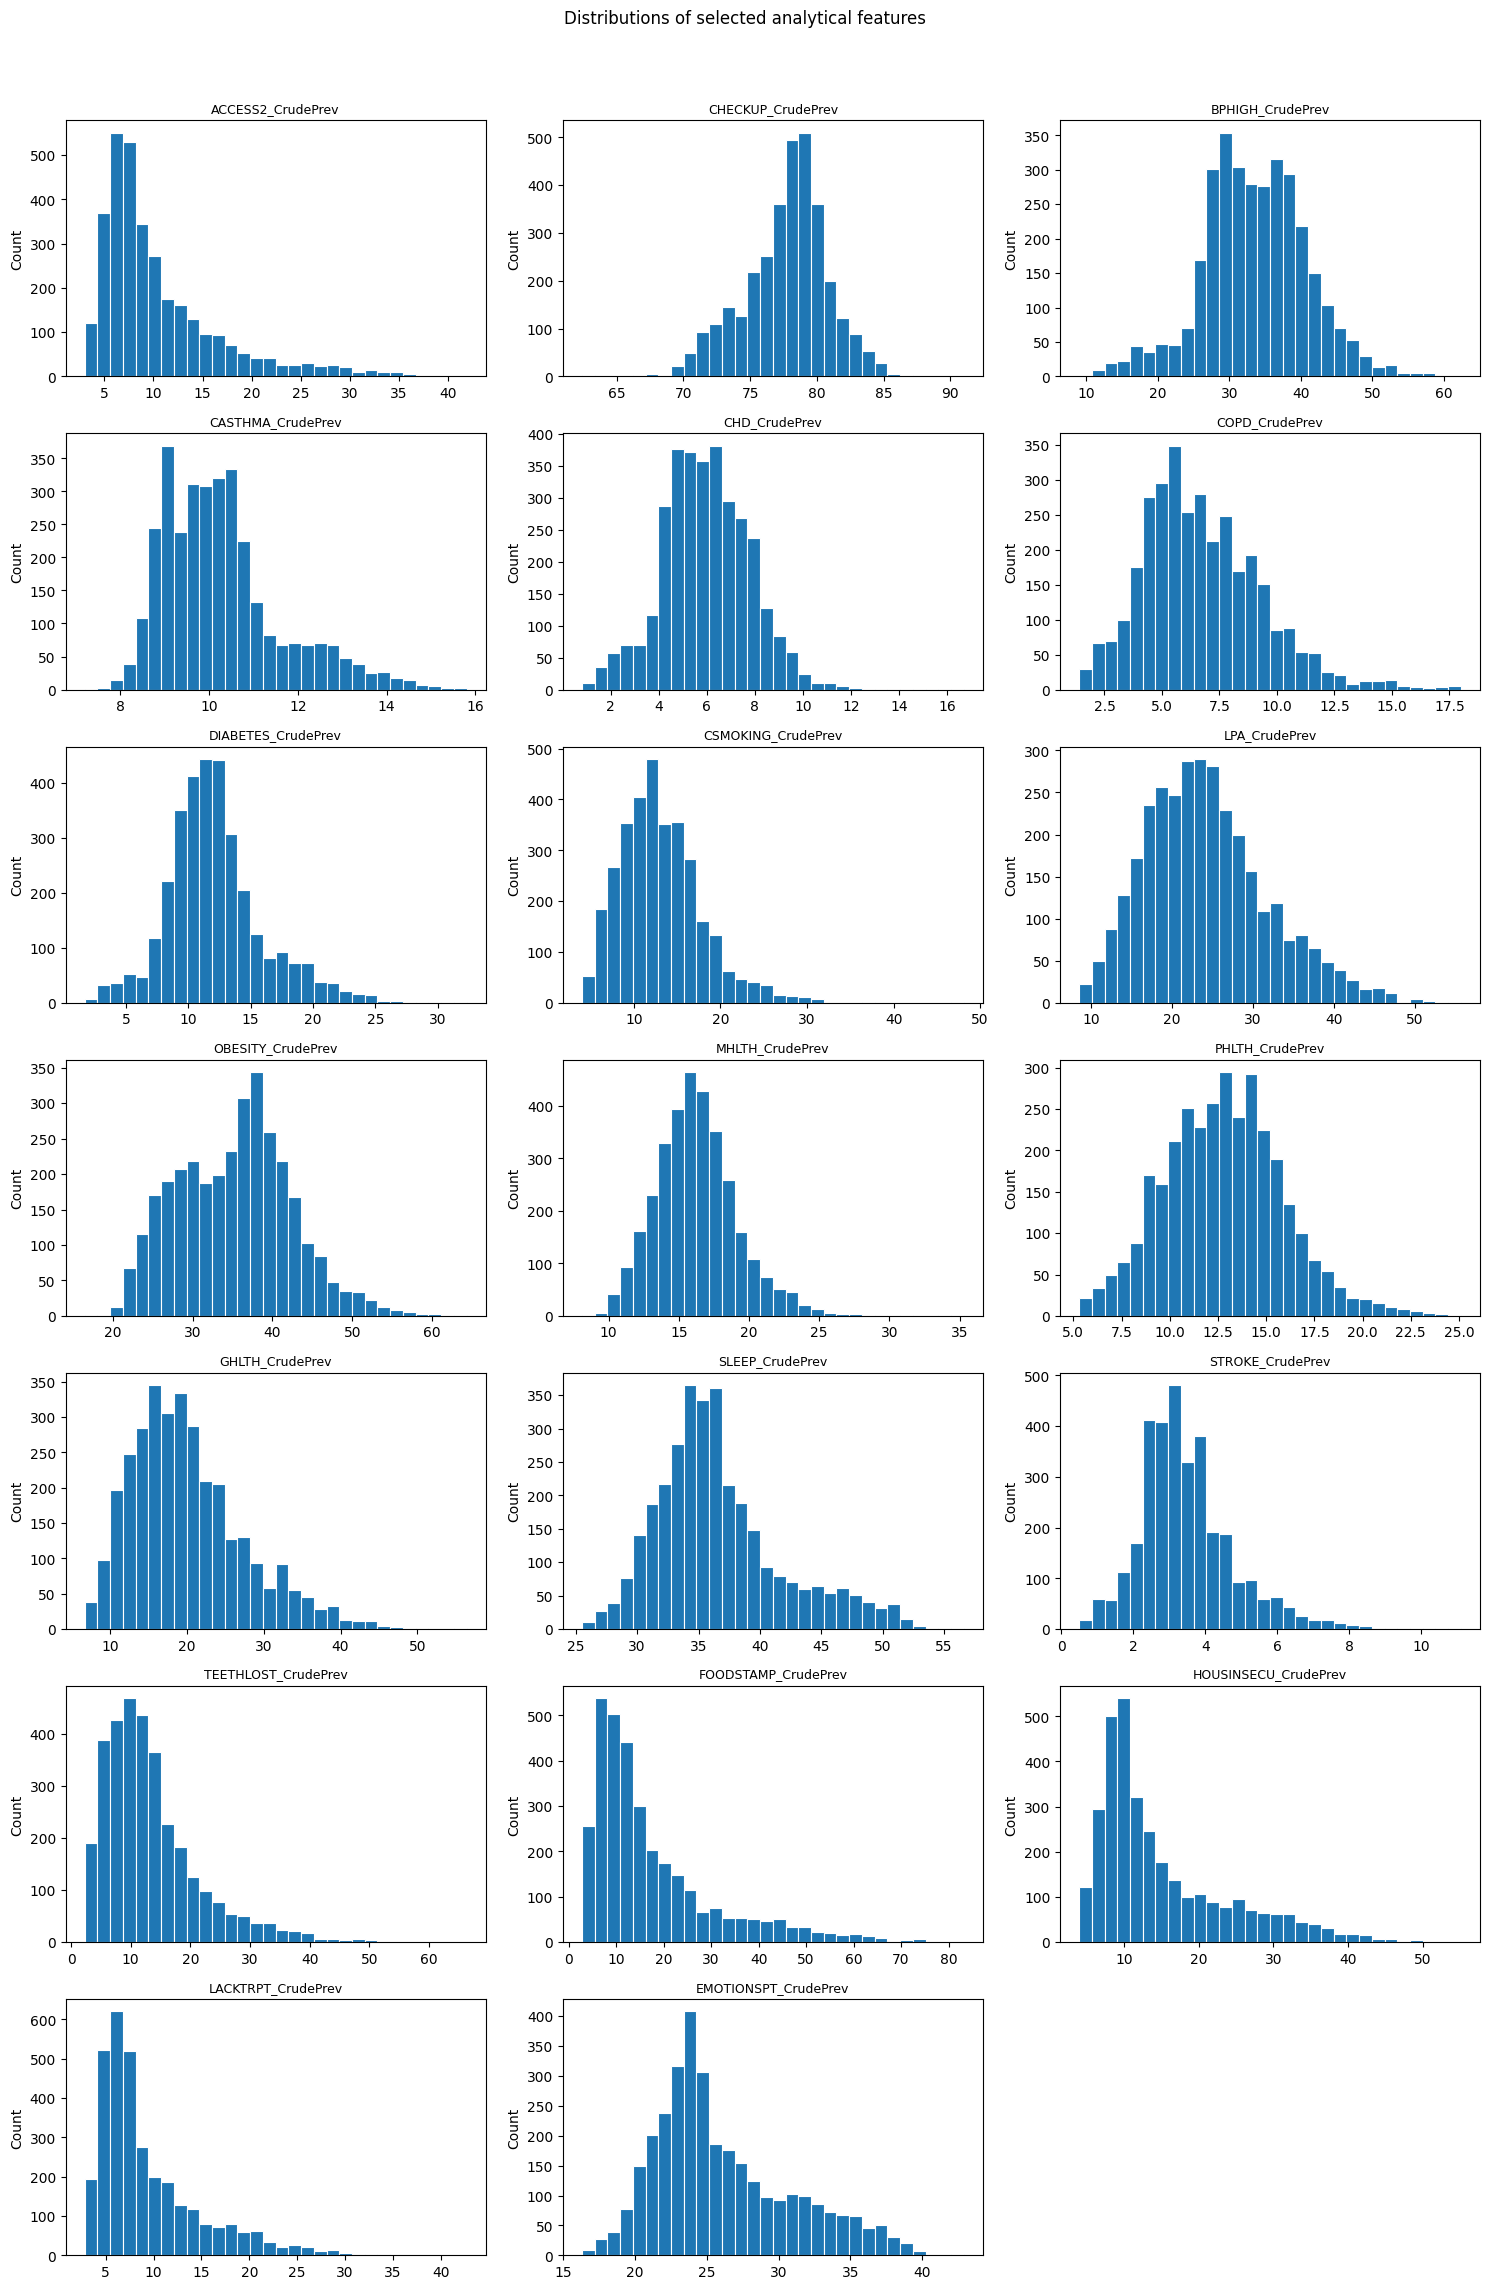

In [83]:
# Distribution plots for the selected analytical features
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))

# Create a grid of subplots to visualize the distribution of each selected analytical feature so that the spread and shape of each feature can be reviewed prior to clustering.
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4, n_rows * 3.2)))
axes = np.array(axes).reshape(-1)

# Loop through each selected feature and create a histogram to show its distribution, which can help identify skewness, outliers, or other characteristics of the data that may impact clustering results.
for ax, col in zip(axes, feature_cols):
    ax.hist(df[col].dropna(), bins=30, edgecolor="white", linewidth=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

# Turn off any unused subplots in the grid so that empty axes do not appear in the figure when the number of features does not fill the entire grid.
for ax in axes[len(feature_cols):]:
    ax.axis("off")

# Add a main title to the figure and save it, then display the plot. This allows for a visual review of the distributions of all selected features in one consolidated view.
plt.suptitle("Distributions of selected analytical features", y=1.02)
plt.tight_layout()
save_fig("distributions_selected_analytical_features", fig)
plt.show()

**🕵️‍♂️ Interpretation/Notes:**<br>
- The histograms show that the tract distributions are not all symmetric (most aren't).
- Several features have long right tails, which suggests that some tracts carry substantially higher burden than the statewide average, which is also visible form the main site with the colored map view.
- This supports the later use of scaling and the decision to review outliers rather than remove them automatically.

Exploring the outliers:

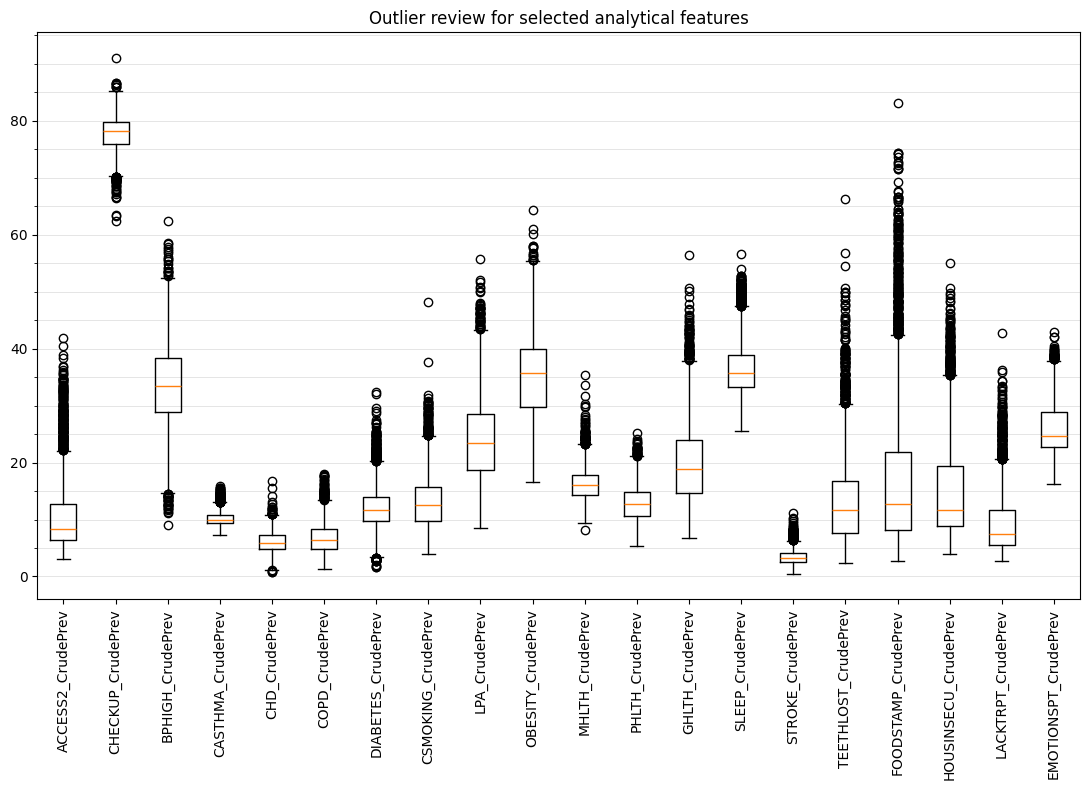

,feature,iqr_outlier_count,iqr_outlier_pct
16,FOODSTAMP_CrudePrev,240,7.366483
0,ACCESS2_CrudePrev,218,6.691222
18,LACKTRPT_CrudePrev,185,5.678330
3,CASTHMA_CrudePrev,171,5.248619
13,SLEEP_CrudePrev,169,5.187231
15,TEETHLOST_CrudePrev,159,4.881793
6,DIABETES_CrudePrev,156,4.788214
17,HOUSINSECU_CrudePrev,129,3.959484
14,STROKE_CrudePrev,114,3.499079
12,GHLTH_CrudePrev,82,2.516882


Saved table: outputs/tables/iqr_outlier_table.csv


In [84]:
# Boxplots and IQR-based outlier counts for analytical features
from matplotlib.ticker import MultipleLocator

def iqr_outlier_count(series):
    x = series.dropna()
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((x < lower) | (x > upper)).sum())

# Create a table that shows the count and percentage of outliers for each selected analytical feature based on the IQR method, sorted by the percentage of outliers in descending order so that features with more extreme values can be reviewed first.
outlier_table = pd.DataFrame({
    "feature": feature_cols,
    "iqr_outlier_count": [iqr_outlier_count(df[c]) for c in feature_cols],
    "iqr_outlier_pct": [100 * iqr_outlier_count(df[c]) / max(1, df[c].notna().sum()) for c in feature_cols],
}).sort_values("iqr_outlier_pct", ascending=False)

# Visualize the outliers for the selected analytical features using boxplots, which can help identify which features have more extreme values and may require special handling prior to clustering.
fig, ax = plt.subplots(figsize=(max(10, len(feature_cols) * 0.55), 8))
ax.boxplot([df[c].dropna() for c in feature_cols], labels=feature_cols, vert=True)
ax.set_xticklabels(feature_cols, rotation=90)
ax.set_title("Outlier review for selected analytical features")
ax.yaxis.set_minor_locator(MultipleLocator(5))
ax.grid(which="major", axis="y", color="lightgrey", linestyle="-", linewidth=0.6, alpha=0.7)
ax.grid(which="minor", axis="y", color="lightgrey", linestyle="-", linewidth=0.6, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
save_fig("outlier_review_selected_features")
plt.show()

# Display the table of outlier counts and percentages for each feature so that the extent of outliers can be reviewed in tabular form as well as visually.
show_table(outlier_table, "iqr_outlier_table", index=False)

# Identify the three features with the largest percentage of IQR-based outliers so that any features with a high rate of extreme values can be noted for potential review or special handling prior to clustering.
top_outliers = outlier_table.head(3)
outlier_text = ", ".join([f"{row.feature} ({row.iqr_outlier_pct:.1f}%)" for _, row in top_outliers.iterrows()])

**🕵️‍♂️ Interpretation/Notes:**<br>
- The features with the largest IQR-based outlier share are FOODSTAMP_CrudePrev (7.4%), ACCESS2_CrudePrev (6.7%), LACKTRPT_CrudePrev (5.7%).
- These high-end values may represent real high-need tracts rather than simple errors, so they are reviewed but not removed automatically.
- This is consistent with the course emphasis on preserving meaningful structure when preparing data for clustering.

Correlation heatmap:

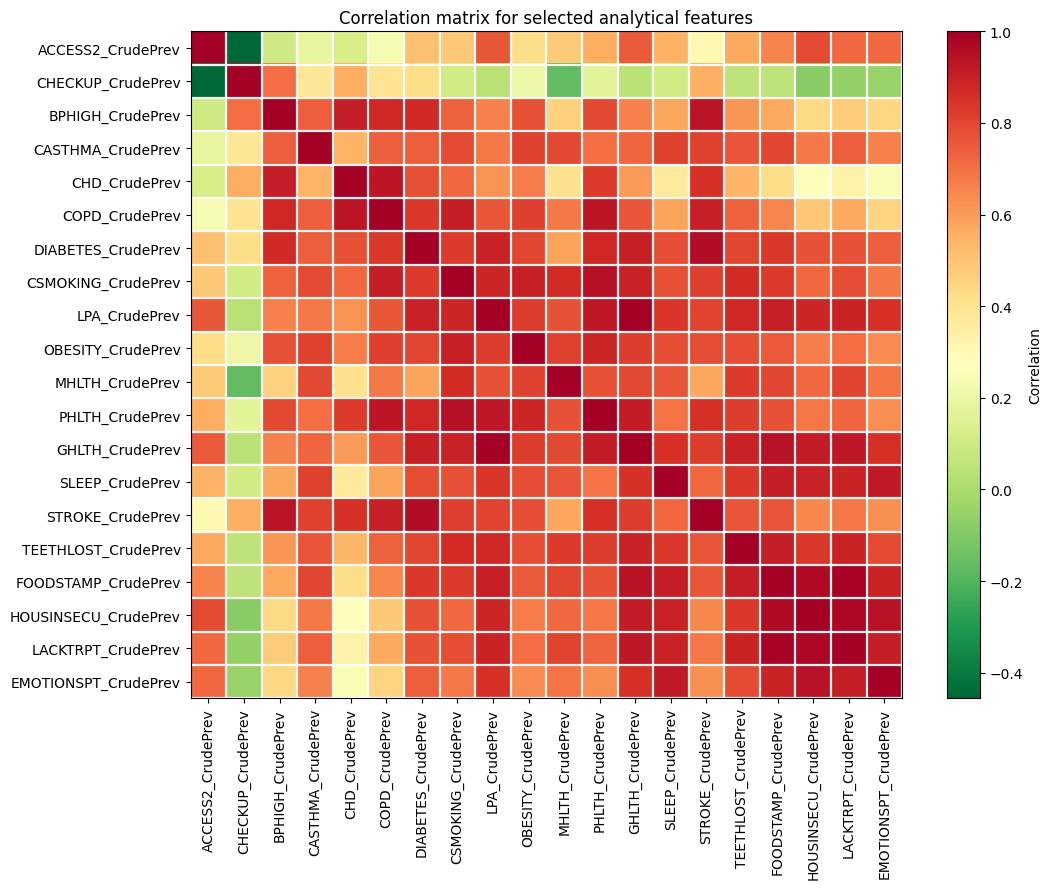

,feature_1,feature_2,correlation,abs_correlation
172,LPA_CrudePrev,GHLTH_CrudePrev,0.990408,0.990408
338,FOODSTAMP_CrudePrev,LACKTRPT_CrudePrev,0.988418,0.988418
358,HOUSINSECU_CrudePrev,LACKTRPT_CrudePrev,0.976365,0.976365
337,FOODSTAMP_CrudePrev,HOUSINSECU_CrudePrev,0.962678,0.962678
134,DIABETES_CrudePrev,STROKE_CrudePrev,0.958901,0.958901
151,CSMOKING_CrudePrev,PHLTH_CrudePrev,0.948557,0.948557
359,HOUSINSECU_CrudePrev,EMOTIONSPT_CrudePrev,0.941065,0.941065
256,GHLTH_CrudePrev,FOODSTAMP_CrudePrev,0.940127,0.940127
54,BPHIGH_CrudePrev,STROKE_CrudePrev,0.935733,0.935733
85,CHD_CrudePrev,COPD_CrudePrev,0.926889,0.926889


Saved table: outputs/tables/top_high_correlation_pairs.csv


In [85]:
# Correlation heatmap among analytical features
corr = df[feature_cols].corr()

# Create a heatmap to visualize the correlation matrix among the selected analytical features, which can help identify any strong correlations or redundancy in the feature set that may impact clustering results.
plt.figure(figsize=(max(9, len(feature_cols) * 0.55), max(7, len(feature_cols) * 0.45)))
im = plt.imshow(corr, aspect="auto", cmap="RdYlGn_r")
plt.colorbar(im, label="Correlation")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)

# Add white borders around each matrix cell for readability.
for x in np.arange(0.5, len(feature_cols), 1):
    plt.axvline(x=x, color="white", linewidth=1.6, alpha=0.95)
for y in np.arange(0.5, len(feature_cols), 1):
    plt.axhline(y=y, color="white", linewidth=1.6, alpha=0.95)

plt.title("Correlation matrix for selected analytical features")
plt.tight_layout()
save_fig("correlation_matrix_selected_features")
plt.show()

# Display a table showing the correlation values for each pair of selected features, sorted by absolute correlation in descending order so that the strongest correlations can be reviewed first.
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()
high_corr_pairs = corr_pairs.sort_values("abs_correlation", ascending=False)

# Display a table showing the feature pairs with the highest absolute correlation values, sorted from strongest to weakest correlation. This helps identify any pairs of features that may be highly redundant and could impact clustering results.
show_table(high_corr_pairs.head(40), "top_high_correlation_pairs", index=False)

n_high = int((high_corr_pairs["abs_correlation"] >= 0.90).sum())

**🕵️‍♂️ Interpretation/Notes:**<br>

The feature set shows substantial redundancy, so PCA and careful interpretation are important.

- There are multiple (about half) feature pairs with absolute correlation of at least 0.90.
- This means the feature set contains strong redundancy and a shared burden pattern.
- Because clustering is distance-based, PCA is used later to reduce this redundancy before model comparison.

In [86]:
# Low-variance check for analytical features
variance_table = (
    df[feature_cols]
    .var(numeric_only=True)
    .sort_values()
    .to_frame("variance")
)

# Display a table showing the variance of each selected analytical feature, sorted from lowest to highest variance so that any features with very low variance can be reviewed for potential exclusion prior to clustering.
show_table(variance_table, "feature_variance_table", index=True)

# Identify the three features with the lowest variance based on the variance values so that any features with very little spread in their values can be noted for potential exclusion prior to clustering.
lowest_var = variance_table.head(3).index.tolist()

,variance
STROKE_CrudePrev,1.692211
CASTHMA_CrudePrev,1.818523
CHD_CrudePrev,3.329369
COPD_CrudePrev,6.663391
MHLTH_CrudePrev,8.540398
PHLTH_CrudePrev,9.545693
CHECKUP_CrudePrev,10.036778
DIABETES_CrudePrev,15.321179
CSMOKING_CrudePrev,22.146685
EMOTIONSPT_CrudePrev,23.304404


Saved table: outputs/tables/feature_variance_table.csv


**🕵️‍♂️ Interpretation/Notes:**<br>

- The lowest-variance features are STROKE_CrudePrev, CASTHMA_CrudePrev, CHD_CrudePrev.
- No feature appears to be completely flat, so the selected set still contains useful variation.
- The bigger issue in this dataset remains the redundancy, not lack of spread.

# Deliverable 2: **Reproducible Notebook**

## 6. Preprocessing and Clustering Readiness

This section prepares the data for clustering:

1. Remove features with too much missingness
2. Impute small gaps (using median)
3. Scale the features
4. Reduce redundancy with PCA

In [87]:
# Build feature matrix and apply a transparent missingness rule
X = df[feature_cols].copy()

# Apply a missingness rule to drop any features with more than a certain percentage of missing values, which helps ensure that the clustering analysis is based on features with sufficient data and reduces the need for imputation or special handling of missing values.
MAX_MISSING_PCT = 20
feature_missing_pct = (X.isna().mean() * 100).sort_values(ascending=False)
keep_features = feature_missing_pct[feature_missing_pct <= MAX_MISSING_PCT].index.tolist()

# Identify which features are dropped due to the missingness rule so that any features with a high rate of missing data that were excluded from clustering can be noted.
dropped_features_missing = [c for c in X.columns if c not in keep_features]
X = X[keep_features].copy()
feature_cols_final = keep_features

# Print the number of features retained after applying the missingness rule and list any features that were dropped due to having more than the specified percentage of missing values.
print("Features retained after missingness rule:", len(feature_cols_final))
print("Dropped for missingness >", MAX_MISSING_PCT, "%:", dropped_features_missing)

# Create a table showing the features that were retained after applying the missingness rule along with their corresponding percentage of missing values, sorted from highest to lowest missingness so that the retained features with the most missing data can be reviewed.
retained_feature_df = pd.DataFrame({
    "final_feature": feature_cols_final,
    "missing_pct": feature_missing_pct.loc[feature_cols_final].values
}).sort_values("missing_pct", ascending=False)
show_table(retained_feature_df, "retained_features_after_missingness_rule", index=False)

Features retained after missingness rule: 20
Dropped for missingness > 20 %: []


,final_feature,missing_pct
0,TEETHLOST_CrudePrev,0.030694
1,ACCESS2_CrudePrev,0.000000
2,BPHIGH_CrudePrev,0.000000
3,CHECKUP_CrudePrev,0.000000
4,CASTHMA_CrudePrev,0.000000
5,CHD_CrudePrev,0.000000
6,DIABETES_CrudePrev,0.000000
7,COPD_CrudePrev,0.000000
8,LPA_CrudePrev,0.000000
9,OBESITY_CrudePrev,0.000000


Saved table: outputs/tables/retained_features_after_missingness_rule.csv


PosixPath('/workspaces/ToU-Clustering/outputs/tables/retained_features_after_missingness_rule.csv')

**🕵️‍♂️ Interpretation/Notes:**<br>

- 20 features (all of the ones identified initially) remain after the missingness rule.
- The missingness rule is simple and transparent, which supports reproducibility.

In [88]:
# Impute missing values with median imputation, which is a common approach for handling missing data in clustering analyses and is less sensitive to outliers than mean imputation.
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)


# Option 1: StandardScaler centers the data to mean 0 and scales to unit variance, which is appropriate when the features are roughly normally distributed and the goal is to treat all features equally in distance calculations.
standard_scaler = StandardScaler().fit(X_imputed)
# Option 2: RobustScaler is less sensitive to outliers, so it can be used as an alternative to StandardScaler if the data has extreme values that could skew the mean and standard deviation.
robust_scaler = RobustScaler().fit(X_imputed)

# Apply both scalers to the imputed data to create two different scaled versions of the feature matrix, which allows for a comparison of how the choice of scaler affects the distribution of the features and potentially the clustering results.
X_standard = standard_scaler.transform(X_imputed)
X_robust = robust_scaler.transform(X_imputed)

# Create a table to compare the standard deviation of each feature after standard scaling and the median value of each feature after robust scaling, which helps illustrate how the different scaling methods affect the distribution of the features.
scale_compare = pd.DataFrame({
    "feature": feature_cols_final,
    "std_after_standard_scaling": X_standard.std(axis=0),
    "median_after_robust_scaling": np.median(X_robust, axis=0)
})

# Display the table comparing the effects of standard scaling and robust scaling on the features, which can help inform the choice of scaler for clustering based on how it impacts the distribution of the features.
show_table(scale_compare, "scaling_comparison_table", index=False)

# Choose which scaler to use for the clustering analysis. By default, StandardScaler is used, but this can be switched to RobustScaler for a sensitivity analysis to see how the choice of scaler affects the clustering results.
SCALER_CHOICE = "standard"                                                              # Alternative: "robust"
scaler_used = standard_scaler if SCALER_CHOICE == "standard" else robust_scaler
X_scaled = X_standard if SCALER_CHOICE == "standard" else X_robust
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols_final, index=X.index)

print("Scaler choice:", SCALER_CHOICE)
print("Scaled matrix shape:", X_scaled_df.shape)
display(X_scaled_df.head())

,feature,std_after_standard_scaling,median_after_robust_scaling
0,TEETHLOST_CrudePrev,1.0,0.000000e+00
1,ACCESS2_CrudePrev,1.0,0.000000e+00
2,BPHIGH_CrudePrev,1.0,0.000000e+00
3,CHECKUP_CrudePrev,1.0,0.000000e+00
4,CASTHMA_CrudePrev,1.0,0.000000e+00
5,CHD_CrudePrev,1.0,0.000000e+00
6,DIABETES_CrudePrev,1.0,0.000000e+00
7,COPD_CrudePrev,1.0,0.000000e+00
8,LPA_CrudePrev,1.0,0.000000e+00
9,OBESITY_CrudePrev,1.0,0.000000e+00


Saved table: outputs/tables/scaling_comparison_table.csv
Scaler choice: standard
Scaled matrix shape: (3258, 20)


,TEETHLOST_CrudePrev,ACCESS2_CrudePrev,BPHIGH_CrudePrev,CHECKUP_CrudePrev,CASTHMA_CrudePrev,CHD_CrudePrev,DIABETES_CrudePrev,COPD_CrudePrev,LPA_CrudePrev,OBESITY_CrudePrev,MHLTH_CrudePrev,CSMOKING_CrudePrev,PHLTH_CrudePrev,GHLTH_CrudePrev,SLEEP_CrudePrev,STROKE_CrudePrev,FOODSTAMP_CrudePrev,HOUSINSECU_CrudePrev,LACKTRPT_CrudePrev,EMOTIONSPT_CrudePrev
24755,0.548327,-0.543288,0.737366,0.690811,0.087666,1.059017,0.120928,0.716847,0.022006,0.258145,-0.094100,0.135931,0.394151,-0.143201,0.069289,0.481909,-0.445743,-0.644943,-0.532078,-0.744016
24756,-0.033893,-0.527311,0.189531,0.027849,0.087666,0.236818,-0.339004,0.174413,-0.189023,0.229976,0.213914,0.157183,0.038065,-0.358970,0.069289,-0.133168,-0.468230,-0.566110,-0.495841,-0.453964
24757,0.127147,-0.543288,-0.769181,-0.950810,0.235998,-0.749821,-0.977797,-0.445511,-0.545134,-0.037633,0.932613,-0.204111,-0.512251,-0.615196,0.126926,-0.748244,-0.460734,-0.509800,-0.296537,-0.371092
24758,0.734142,-0.048004,1.463248,0.375115,0.829330,2.538975,1.142997,2.150424,1.235424,1.201818,1.206403,1.687371,1.624269,1.057017,0.722507,1.635179,0.686089,0.177176,0.428205,0.043267
24759,1.564116,-0.095935,1.052372,0.217266,0.977663,1.442709,0.683066,1.685480,0.998016,1.060971,1.172179,1.411087,1.300554,0.773819,0.895417,1.096986,0.543673,0.098343,0.319494,-0.060323


**🕵️‍♂️ Interpretation/Notes:**<br>

- The main workflow uses standard scaling.
- Standard scaling is a strong baseline here because the selected features are all prevalence-style numeric measures and the main goal is fair distance comparison across variables.
- If needed, it's possible to change to the `robust` scalar.

Applying PCA for dimensionality reduction:

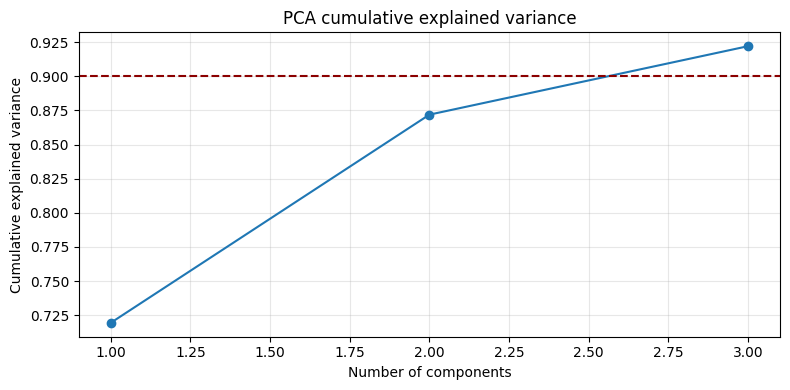

Original selected feature count: 20
PCA component count: 3


,PC1,PC2,PC3
TEETHLOST_CrudePrev,0.242,-0.075,-0.002
ACCESS2_CrudePrev,0.156,-0.364,-0.237
BPHIGH_CrudePrev,0.205,0.346,0.066
CHECKUP_CrudePrev,0.051,0.485,0.448
CASTHMA_CrudePrev,0.222,0.100,0.288
CHD_CrudePrev,0.180,0.367,-0.300
DIABETES_CrudePrev,0.246,0.116,0.083
COPD_CrudePrev,0.223,0.248,-0.260
LPA_CrudePrev,0.253,-0.086,-0.125
OBESITY_CrudePrev,0.235,0.073,-0.119


Saved table: outputs/tables/pca_loadings_first_components.csv


PosixPath('/workspaces/ToU-Clustering/outputs/tables/pca_loadings_first_components.csv')

In [89]:
# Apply PCA to reduce dimensionality of the scaled feature matrix while retaining a target proportion of variance, which can help improve clustering performance by reducing noise and multicollinearity among features.

USE_PCA = True                 # Set to False to skip PCA and use the full scaled feature matrix for clustering
PCA_VARIANCE_TARGET = 0.90     # Target proportion of variance to retain with PCA

# Initialize PCA with the target explained variance and fit it to the scaled feature matrix to obtain the principal components that capture the majority of the variance in the data.
pca = PCA(n_components=PCA_VARIANCE_TARGET, random_state=RANDOM_STATE)
# Transform the scaled feature matrix using the fitted PCA to obtain the reduced-dimensionality representation of the data that will be used for clustering.
X_pca = pca.fit_transform(X_scaled)

# Calculate the explained variance ratio for each principal component and the cumulative explained variance to understand how much of the original variance is retained by the PCA transformation, which can help inform the choice of how many components to retain for clustering.
explained_ratio = pca.explained_variance_ratio_
cumulative_explained = np.cumsum(explained_ratio)

# Create a plot to visualize the cumulative explained variance as a function of the number of principal components, with a horizontal line indicating the target variance threshold, which helps illustrate how many components are needed to retain the desired amount of variance in the data.
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_explained) + 1), cumulative_explained, marker="o")
plt.axhline(PCA_VARIANCE_TARGET, linestyle="--", color="darkred")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("pca_cumulative_explained_variance")
plt.show()

# Print the number of original features and the number of PCA components retained to give a sense of the dimensionality reduction achieved by PCA.
print("Original selected feature count:", X_scaled.shape[1])
print("PCA component count:", X_pca.shape[1])

# Create a table showing the PCA loadings for the first few principal components to understand how the original features contribute to each component, which can help interpret the latent dimensions identified by PCA.
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols_final,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
 )
show_table(pca_loadings.iloc[:, :min(5, pca_loadings.shape[1])].round(3), "pca_loadings_first_components", index=True)

**🕵️‍♂️ Interpretation/Notes:**<br>

- PCA reduces the working space from 20 features to 3 components.
- This confirms that a few latent dimensions explain much of the tract-level variation.

In [90]:
# Choose the matrix used for clustering
X_cluster = X_pca if USE_PCA else X_scaled

print("Clustering matrix shape:\n", X_cluster.shape)
print("Using PCA for clustering:\n" , USE_PCA)

Clustering matrix shape:
 (3258, 3)
Using PCA for clustering:
 True


**🕵️‍♂️ Interpretation/Notes:**<br>

- The clustering matrix has shape (3258, 3).

In [91]:
# Clustering-readiness diagnostics: redundancy summary and Hopkins statistic
def hopkins_statistic(X_input, sample_size=500, random_state=42):
    """Estimate cluster tendency. Values near 0.5 suggest randomness; values closer to 1 suggest stronger cluster tendency."""
    rng = np.random.default_rng(random_state)
    X_arr = np.asarray(X_input)
    n_rows, n_cols = X_arr.shape
    sample_size = int(min(sample_size, max(25, n_rows // 5), n_rows - 1))

    if sample_size < 10:
        return np.nan

    mins = X_arr.min(axis=0)
    maxs = X_arr.max(axis=0)

    sample_idx = rng.choice(np.arange(n_rows), size=sample_size, replace=False)
    X_sample = X_arr[sample_idx]
    X_uniform = rng.uniform(mins, maxs, size=(sample_size, n_cols))

    nn_full = NearestNeighbors(n_neighbors=2).fit(X_arr)
    u_dist, _ = nn_full.kneighbors(X_uniform, n_neighbors=1)
    w_dist, _ = nn_full.kneighbors(X_sample, n_neighbors=2)

    u_sum = u_dist[:, 0].sum()
    w_sum = w_dist[:, 1].sum()

    return float(u_sum / (u_sum + w_sum))

abs_corr = X_scaled_df.corr().abs()
upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_correlation"})
    .sort_values("abs_correlation", ascending=False)
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_correlation"] >= 0.90].reset_index(drop=True)

hopkins_value = hopkins_statistic(X_cluster, sample_size=min(500, len(X_cluster) - 1), random_state=RANDOM_STATE)

readiness_summary = pd.DataFrame([{
    "observations": X_cluster.shape[0],
    "features_after_missingness": len(feature_cols_final),
    "features_used_for_clustering": X_cluster.shape[1],
    "high_correlation_pairs_ge_0_90": int(len(high_corr_pairs)),
    "hopkins_statistic": round(hopkins_value, 3) if pd.notna(hopkins_value) else np.nan
}])

show_table(readiness_summary, "clustering_readiness_summary", index=False)

print("Top high-correlation feature pairs (|r| >= 0.90):")
show_table(high_corr_pairs.head(15), "high_correlation_feature_pairs_top15", index=False)

# Interpret result
if hopkins_value > 0.75:
    interpretation = "✅ EXCELLENT clustering tendency - proceed with confidence"
    recommendation = "Your data has strong clustering structure"
elif hopkins_value > 0.7:
    interpretation = "✅ GOOD clustering tendency - safe to proceed"
    recommendation = "Your data is suitable for clustering"
elif hopkins_value > 0.6:
    interpretation = "⚠️ MODERATE clustering tendency - use caution"
    recommendation = "Clustering may work, but validate results carefully"
else:
    interpretation = "❌ NO clustering tendency - consider other methods"
    recommendation = "Your data appears random - clustering not recommended"

print("\n\nClustering Readiness Assessment:\n")
print(f"Assessment:\n {interpretation}")
print(f"Recommendation:\n {recommendation}")

,observations,features_after_missingness,features_used_for_clustering,high_correlation_pairs_ge_0_90,hopkins_statistic
0,3258,20,3,24,0.896


Saved table: outputs/tables/clustering_readiness_summary.csv
Top high-correlation feature pairs (|r| >= 0.90):


,feature_1,feature_2,abs_correlation
0,LPA_CrudePrev,GHLTH_CrudePrev,0.990408
1,FOODSTAMP_CrudePrev,LACKTRPT_CrudePrev,0.988418
2,HOUSINSECU_CrudePrev,LACKTRPT_CrudePrev,0.976365
3,FOODSTAMP_CrudePrev,HOUSINSECU_CrudePrev,0.962678
4,DIABETES_CrudePrev,STROKE_CrudePrev,0.958901
5,CSMOKING_CrudePrev,PHLTH_CrudePrev,0.948557
6,HOUSINSECU_CrudePrev,EMOTIONSPT_CrudePrev,0.941065
7,GHLTH_CrudePrev,FOODSTAMP_CrudePrev,0.940127
8,BPHIGH_CrudePrev,STROKE_CrudePrev,0.935733
9,CHD_CrudePrev,COPD_CrudePrev,0.926889


Saved table: outputs/tables/high_correlation_feature_pairs_top15.csv


Clustering Readiness Assessment:

Assessment:
 ✅ EXCELLENT clustering tendency - proceed with confidence
Recommendation:
 Your data has strong clustering structure


**🕵️‍♂️ Interpretation/Notes:**<br>

- The Hopkins statistic is 0.896, which supports cluster tendency rather than a random pattern.

## 7. Clustering Experiments and Validation

Three algorithm families are compared:
1. **K-means** for compact centroid-based groups,
2. **Agglomerative clustering** for a hierarchical comparison,
3. **DBSCAN** for density-based structure and possible noise points.

Solutions are compared using:

- **Silhouette score**,
- **Davies–Bouldin index**,
- **Calinski–Harabasz score**,
- **Cluster-size balance**,
- **Stability check** for the final K-means model.

Helper functions:

In [92]:
# Function: evaluate_clustering
# The function takes the input feature matrix, the cluster labels assigned to each observation, and an optional algorithm name for reference. It returns a dictionary containing the evaluation metrics and cluster characteristics that can be used for comparison across different clustering algorithms or parameter settings.
def evaluate_clustering(X_input, labels, algorithm_name=None):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    # Mask and subset the labels to exclude noise points (-1) for metrics that only make sense on actual clusters, and identify the unique non-noise cluster labels for later use in calculating metrics and cluster size characteristics.
    non_noise_mask = labels != -1
    non_noise_labels = labels[non_noise_mask]
    non_noise_unique = np.unique(non_noise_labels)

    # Percentage of observations labeled as noise (-1) among all observations, which gives a sense of how much of the data was considered noise by the clustering algorithm.
    noise_pct = float((labels == -1).mean() * 100)

    # If there are fewer than 2 non-noise clusters, clustering evaluation metrics that require at least 2 clusters are undefined
    if len(non_noise_unique) < 2:
        sil = np.nan
        dbi = np.nan
        chs = np.nan
        n_clusters = len(non_noise_unique)
    else:
        X_eval = X_input[non_noise_mask] if noise_pct > 0 else X_input
        y_eval = non_noise_labels if noise_pct > 0 else labels
        sil = silhouette_score(X_eval, y_eval)
        dbi = davies_bouldin_score(X_eval, y_eval)
        chs = calinski_harabasz_score(X_eval, y_eval)
        n_clusters = len(np.unique(y_eval))

    cluster_counts = pd.Series(non_noise_labels).value_counts().sort_index() if len(non_noise_labels) else pd.Series(dtype=int)
    min_cluster_size = int(cluster_counts.min()) if len(cluster_counts) else 0
    max_cluster_size = int(cluster_counts.max()) if len(cluster_counts) else 0
    balance_ratio = (min_cluster_size / max_cluster_size) if max_cluster_size > 0 else np.nan

    return {
        "algorithm": algorithm_name,                                # Optional name of the clustering algorithm or parameter setting for reference
        "n_clusters": int(n_clusters),                              # Number of clusters found (excluding noise points)
        "silhouette": sil,                                          # Silhouette score for the clustering (higher is better)  
        "davies_bouldin": dbi,                                      # Davies-Bouldin index (lower is better)
        "calinski_harabasz": chs,                                   # Calinski-Harabasz score (higher is better)    
        "noise_pct": noise_pct,                                     # Percentage of observations labeled as noise (-1)
        "min_cluster_size": min_cluster_size,                       # Size of the smallest cluster (excluding noise)
        "max_cluster_size": max_cluster_size,                       # Size of the largest cluster (excluding noise)
        "balance_ratio": balance_ratio,                             # Ratio of smallest to largest cluster size (min / max)
        "cluster_sizes_non_noise": cluster_counts.to_dict()         # Dictionary of cluster sizes for each non-noise cluster
    }

# Function: result_to_row
# This helper function converts the dictionary returned by evaluate_clustering into a flat dictionary suitable for tabular display or storage, excluding keys that are not scalar values or are not needed for summary tables (like the model object, raw labels, or the detailed cluster size dictionary).
def result_to_row(result_dict):
    excluded = {"model_object", "labels", "cluster_sizes_non_noise"}
    return {k: v for k, v in result_dict.items() if k not in excluded}

### 7.1. K-Means

This section runs a grid of K-means clustering experiments over a range of k values, collects evaluation metrics for each run, and stores the inertia for elbow plot analysis.

,algorithm,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_pct,min_cluster_size,max_cluster_size,balance_ratio,params
0,KMeans,3,0.376366,0.934700,3077.872148,0.0,454,1498,0.303071,k=3
1,KMeans,4,0.399120,0.877678,2956.945483,0.0,405,1269,0.319149,k=4
2,KMeans,5,0.332584,0.931179,2779.408692,0.0,364,1020,0.356863,k=5
3,KMeans,6,0.334149,0.976800,2714.139837,0.0,170,980,0.173469,k=6
4,KMeans,7,0.331055,0.957290,2641.325447,0.0,168,784,0.214286,k=7


Saved table: outputs/tables/kmeans_experiment_results.csv


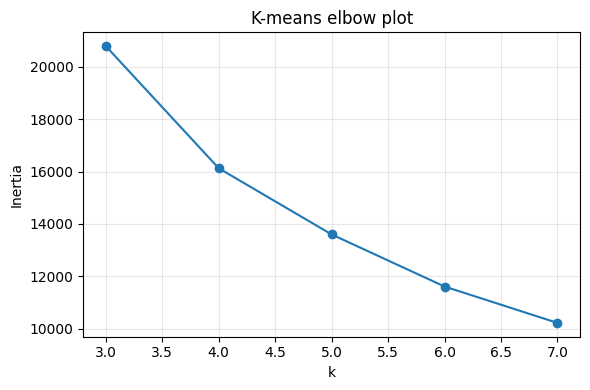

In [93]:
# K-means experiments


kmeans_results = []            # List to store the results of K-means clustering experiments with different values of k, including evaluation metrics and cluster characteristics for each k.
k_grid = [3, 4, 5, 6, 7]       # Grid of k values to experiment with for K-means clustering, which allows for a systematic evaluation of how the number of clusters affects the clustering results and helps identify a suitable range of k values for further analysis.
kmeans_inertia = []            # List to store the inertia values for each k in the K-means experiments, which is used to create the elbow plot for visually assessing the appropriate number of clusters.

# Loop through each value of k in the grid, fit a KMeans model to the clustering matrix, predict cluster labels, evaluate the clustering results using the evaluate_clustering function, and store the results along with the model object and labels for later analysis and comparison across different k values.
for k in k_grid:
    model = KMeans(n_clusters=k, n_init=50, max_iter=500, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_cluster)
    metrics = evaluate_clustering(X_cluster, labels, algorithm_name="KMeans")
    metrics.update({
        "params": f"k={k}",
        "model_object": model,
        "labels": labels
    })
    kmeans_results.append(metrics)
    kmeans_inertia.append({"k": k, "inertia": model.inertia_})

# Create a DataFrame from the K-means results for easier comparison and display, and show it in a table format so that the evaluation metrics for each value of k can be reviewed side by side to inform the choice of k for clustering.
kmeans_results_df = pd.DataFrame([result_to_row(r) for r in kmeans_results])
show_table(kmeans_results_df, "kmeans_experiment_results", index=False)

# Create an elbow plot using the inertia values from the K-means experiments to visually assess the appropriate number of clusters, which can help identify a point where adding more clusters does not significantly improve the fit of the model (the "elbow" point).
inertia_df = pd.DataFrame(kmeans_inertia)
plt.figure(figsize=(6, 4))
plt.plot(inertia_df["k"], inertia_df["inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("K-means elbow plot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("kmeans_elbow_plot")
plt.show()

best_kmeans_row = kmeans_results_df.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]

**🕵️‍♂️ Interpretation/Notes:**<br>

- The K-means grid provides the main candidate solutions for a balanced stakeholder-facing segmentation.
- The strongest K-means result by silhouette in this grid is k=4 with silhouette 0.399.

### 7.2. Agglomerative experiments

Interpret the K-means results by identifying the best-performing k value based on silhouette score and Davies-Bouldin index, and provide an interpretation of what this means for the clustering structure in the data.



In [94]:
agg_results = []

# Loop through a grid of k values and linkage methods for Agglomerative Clustering, fit the model, predict cluster labels, evaluate the clustering results using the evaluate_clustering function, and store the results along with the model object and labels for later analysis and comparison across different parameter settings.
for k in [3, 4, 5, 6]:
    for linkage_name in ["ward", "complete", "average"]:
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage_name)
        labels = model.fit_predict(X_cluster)
        metrics = evaluate_clustering(X_cluster, labels, algorithm_name="Agglomerative")
        metrics.update({
            "params": f"k={k}, linkage={linkage_name}",
            "model_object": model,
            "labels": labels
        })
        agg_results.append(metrics)

# Create a DataFrame from the Agglomerative Clustering results for easier comparison and display, and show it in a table format so that the evaluation metrics for each combination of k and linkage method can be reviewed side by side to inform the choice of parameters for clustering.
agg_results_df = pd.DataFrame([result_to_row(r) for r in agg_results])
show_table(agg_results_df, "agglomerative_experiment_results", index=False)

# Identify the best-performing combination of k and linkage method based on silhouette score (higher is better) and Davies-Bouldin index (lower is better), and provide an interpretation of what this means for the clustering structure in the data.
best_agg_row = agg_results_df.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]

,algorithm,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_pct,min_cluster_size,max_cluster_size,balance_ratio,params
0,Agglomerative,3,0.375177,0.959330,2885.642575,0.0,358,1606,0.222914,"k=3, linkage=ward"
1,Agglomerative,3,0.459074,0.888916,1080.315794,0.0,49,2933,0.016706,"k=3, linkage=complete"
2,Agglomerative,3,0.480005,0.538033,942.943421,0.0,1,2970,0.000337,"k=3, linkage=average"
3,Agglomerative,4,0.366245,0.957493,2560.016900,0.0,358,1606,0.222914,"k=4, linkage=ward"
4,Agglomerative,4,0.440309,0.745316,725.389569,0.0,1,2933,0.000341,"k=4, linkage=complete"
5,Agglomerative,4,0.465497,0.589707,643.992227,0.0,1,2970,0.000337,"k=4, linkage=average"
6,Agglomerative,5,0.306484,1.028102,2490.721993,0.0,358,1024,0.349609,"k=5, linkage=ward"
7,Agglomerative,5,0.310599,0.898718,1231.634689,0.0,1,2016,0.000496,"k=5, linkage=complete"
8,Agglomerative,5,0.462430,0.504288,483.953624,0.0,1,2970,0.000337,"k=5, linkage=average"
9,Agglomerative,6,0.284562,1.125276,2298.422932,0.0,276,1024,0.269531,"k=6, linkage=ward"


Saved table: outputs/tables/agglomerative_experiment_results.csv


**🕵️‍♂️ Interpretation/Notes:**<br>

- The strongest agglomerative result in this grid is k=3, linkage=average with silhouette 0.480.

### 7.3. DBSCAN experiments

Perform a grid search over DBSCAN hyperparameters (eps and min_samples), fit the model, evaluate the clustering results, and store the results for later comparison with K-means and agglomerative clustering.

In [95]:
dbscan_results = []

# Loop through a grid of eps and min_samples values for DBSCAN, fit the model, predict cluster labels, evaluate the clustering results using the evaluate_clustering function, and store the results along with the model object and labels for later analysis and comparison across different parameter settings. This allows for a systematic evaluation of how the density-based clustering structure changes with different settings of eps and min_samples.
for eps in [0.8, 1.0, 1.2, 1.4, 1.6]:
    for min_samples in [5, 10, 15]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_cluster)
        metrics = evaluate_clustering(X_cluster, labels, algorithm_name="DBSCAN")
        metrics.update({
            "params": f"eps={eps}, min_samples={min_samples}",
            "model_object": model,
            "labels": labels
        })
        dbscan_results.append(metrics)

# Create a DataFrame from the DBSCAN results for easier comparison and display, and show the top 15 results sorted by number of clusters and silhouette score so that the most promising parameter combinations can be quickly reviewed.
dbscan_results_df = pd.DataFrame([result_to_row(r) for r in dbscan_results])
dbscan_preview = dbscan_results_df.sort_values(["n_clusters", "silhouette"], ascending=[False, False]).head(15)
show_table(dbscan_preview, "dbscan_experiment_results_top15", index=False)

usable_dbscan = dbscan_results_df.dropna(subset=["silhouette"])

,algorithm,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_pct,min_cluster_size,max_cluster_size,balance_ratio,params
0,DBSCAN,4,0.228159,0.551133,18.527517,4.910988,3,3083,0.000973,"eps=0.8, min_samples=5"
1,DBSCAN,3,0.423074,0.696065,702.652126,8.931860,36,2703,0.013319,"eps=0.8, min_samples=10"
2,DBSCAN,3,0.240622,0.720372,490.412221,12.523020,16,2649,0.006040,"eps=0.8, min_samples=15"
3,DBSCAN,2,0.590259,0.305855,55.646423,2.455494,5,3173,0.001576,"eps=1.0, min_samples=5"
5,DBSCAN,2,0.469365,0.729587,1406.087123,6.875384,296,2738,0.108108,"eps=1.0, min_samples=15"
9,DBSCAN,2,0.340985,0.652506,19.771310,0.767342,7,3226,0.002170,"eps=1.4, min_samples=5"
4,DBSCAN,2,0.292187,0.600061,27.117156,4.696133,9,3096,0.002907,"eps=1.0, min_samples=10"
6,DBSCAN,1,NaN,NaN,NaN,1.350522,3214,3214,1.000000,"eps=1.2, min_samples=5"
7,DBSCAN,1,NaN,NaN,NaN,2.762431,3168,3168,1.000000,"eps=1.2, min_samples=10"
8,DBSCAN,1,NaN,NaN,NaN,3.683241,3138,3138,1.000000,"eps=1.2, min_samples=15"


Saved table: outputs/tables/dbscan_experiment_results_top15.csv


**🕵️‍♂️ Interpretation/Notes:**<br>
- The strongest DBSCAN result in this grid is eps=1.0, min_samples=5 with silhouette 0.590.
- Because DBSCAN can produce very imbalanced solutions, it is treated as a diagnostic rather than the default final model (separate tests showed that it produces a single dominant cluster which wasn't useful).

### 7.4. Compare results

Combine experiment results, rank them, and flag potentially degenerate solutions:
Identify the best-performing combination of eps and min_samples for DBSCAN based on silhouette score (higher is better) and Davies-Bouldin index (lower is better), and provide an interpretation of what this means for the density-based clustering structure in the data.



In [96]:
# Combine the results from K-means, Agglomerative Clustering, and DBSCAN into a single DataFrame for overall comparison and ranking of clustering solutions across algorithms.
# This allows for a comprehensive review of all clustering results in one place, with the ability to compare different algorithms and parameter settings based on their evaluation metrics and cluster characteristics.
all_results = kmeans_results + agg_results + dbscan_results

# Convert the combined list of clustering results into a DataFrame where each row corresponds to a single experiment's results, making it easier to sort, filter, and rank the clustering solutions across all algorithms.
results_df = pd.DataFrame([result_to_row(r) for r in all_results]).copy()

# Create new columns in the results DataFrame to flag which solutions are valid based on having a reasonable number of clusters (between 2 and 8) and a defined silhouette score, as well as to calculate the share of the largest cluster and identify potentially degenerate structures (tiny clusters or dominant clusters) that may not be actionable for stakeholder-facing segmentation.
results_df["valid_solution"] = (
    results_df["n_clusters"].between(2, 8)
    & results_df["silhouette"].notna()
)

# Calculate the share of the largest cluster relative to the total number of observations to identify solutions where one cluster dominates the segmentation, which may not be desirable for actionable insights.
results_df["largest_cluster_share"] = results_df["max_cluster_size"] / len(df)
min_reasonable_cluster = max(25, int(len(df) * 0.01))

# Flag solutions with tiny clusters (smaller than the minimum reasonable cluster size) or dominant clusters (where one cluster accounts for more than 75% of the observations) as potentially degenerate structures that may not be useful for stakeholder-facing segmentation, even if they have good evaluation metrics.
results_df["tiny_cluster_flag"] = results_df["min_cluster_size"] < min_reasonable_cluster
results_df["dominant_cluster_flag"] = results_df["largest_cluster_share"] > 0.75
results_df["degenerate_structure_flag"] = (
    results_df["tiny_cluster_flag"] | results_df["dominant_cluster_flag"]
)

# Create a composite ranking score that combines the evaluation metrics and cluster characteristics to rank the clustering solutions, giving more weight to silhouette score and penalizing solutions with high Davies-Bouldin index, high noise percentage, and poor balance between cluster sizes. This allows for an overall ranking of the clustering solutions that takes into account multiple factors relevant to the quality and actionability of the segmentation.
results_df["ranking_score"] = (
    results_df["silhouette"].fillna(-999) * 100
    - results_df["davies_bouldin"].fillna(999) * 10
    + np.log1p(results_df["calinski_harabasz"].fillna(0))
    - results_df["noise_pct"].fillna(0) * 0.25
    + results_df["balance_ratio"].fillna(0) * 5
)

# Sort the results DataFrame by the valid_solution flag, ranking score, silhouette score, and Davies-Bouldin index to identify the top overall clustering solutions, while also allowing for a review of potentially degenerate structures that may have high metrics but are not actionable for stakeholder-facing segmentation.
results_df = results_df.sort_values(
    by=["valid_solution", "ranking_score", "silhouette", "davies_bouldin"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

# Display the top 20 overall clustering results, including those that may be degenerate, so that the user can see which solutions scored highest on the composite ranking even if they include tiny or dominant clusters that may not be actionable.
print("Top overall results (including potentially degenerate structures):")
show_table(results_df.head(20), "all_clustering_results_top20", index=False)

# Display the top 15 clustering results that are considered more balanced and potentially actionable for stakeholder-facing segmentation, filtering out solutions that are flagged as degenerate due to tiny or dominant clusters, so that the user can focus on solutions that are both high-performing and likely to produce meaningful segments.
print("\nMore balanced candidates for stakeholder-facing segmentation:")
balanced_candidates_df = results_df[
    results_df["valid_solution"] & ~results_df["degenerate_structure_flag"]
].reset_index(drop=True)
show_table(balanced_candidates_df.head(15), "balanced_segmentation_candidates_top15", index=False)

Top overall results (including potentially degenerate structures):


,algorithm,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_pct,min_cluster_size,max_cluster_size,balance_ratio,params,valid_solution,largest_cluster_share,tiny_cluster_flag,dominant_cluster_flag,degenerate_structure_flag,ranking_score
0,DBSCAN,2,0.590259,0.305855,55.646423,2.455494,5,3173,0.001576,"eps=1.0, min_samples=5",True,0.973910,True,True,True,59.398153
1,Agglomerative,3,0.480005,0.538033,942.943421,0.000000,1,2970,0.000337,"k=3, linkage=average",True,0.911602,True,True,True,49.471934
2,Agglomerative,5,0.462430,0.504288,483.953624,0.000000,1,2970,0.000337,"k=5, linkage=average",True,0.911602,True,True,True,47.385848
3,Agglomerative,4,0.465497,0.589707,643.992227,0.000000,1,2970,0.000337,"k=4, linkage=average",True,0.911602,True,True,True,47.123558
4,DBSCAN,2,0.469365,0.729587,1406.087123,6.875384,296,2738,0.108108,"eps=1.0, min_samples=15",True,0.840393,False,True,True,45.711595
5,Agglomerative,3,0.459074,0.888916,1080.315794,0.000000,49,2933,0.016706,"k=3, linkage=complete",True,0.900246,False,True,True,44.087752
6,Agglomerative,4,0.440309,0.745316,725.389569,0.000000,1,2933,0.000341,"k=4, linkage=complete",True,0.900246,True,True,True,43.167496
7,KMeans,4,0.399120,0.877678,2956.945483,0.000000,405,1269,0.319149,k=4,True,0.389503,False,False,False,40.723231
8,DBSCAN,3,0.423074,0.696065,702.652126,8.931860,36,2703,0.013319,"eps=0.8, min_samples=10",True,0.829650,False,True,True,39.736635
9,KMeans,3,0.376366,0.934700,3077.872148,0.000000,454,1498,0.303071,k=3,True,0.459791,False,False,False,37.837260


Saved table: outputs/tables/all_clustering_results_top20.csv

More balanced candidates for stakeholder-facing segmentation:


,algorithm,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_pct,min_cluster_size,max_cluster_size,balance_ratio,params,valid_solution,largest_cluster_share,tiny_cluster_flag,dominant_cluster_flag,degenerate_structure_flag,ranking_score
0,KMeans,4,0.399120,0.877678,2956.945483,0.0,405,1269,0.319149,k=4,True,0.389503,False,False,False,40.723231
1,KMeans,3,0.376366,0.934700,3077.872148,0.0,454,1498,0.303071,k=3,True,0.459791,False,False,False,37.837260
2,Agglomerative,3,0.375177,0.959330,2885.642575,0.0,358,1606,0.222914,"k=3, linkage=ward",True,0.492940,False,False,False,37.006860
3,Agglomerative,4,0.366245,0.957493,2560.016900,0.0,358,1606,0.222914,"k=4, linkage=ward",True,0.492940,False,False,False,36.012346
4,KMeans,5,0.332584,0.931179,2779.408692,0.0,364,1020,0.356863,k=5,True,0.313076,False,False,False,33.661276
5,KMeans,7,0.331055,0.957290,2641.325447,0.0,168,784,0.214286,k=7,True,0.240638,False,False,False,32.483450
6,KMeans,6,0.334149,0.976800,2714.139837,0.0,170,980,0.173469,k=6,True,0.300798,False,False,False,32.420856
7,Agglomerative,5,0.306484,1.028102,2490.721993,0.0,358,1024,0.349609,"k=5, linkage=ward",True,0.314303,False,False,False,29.936155
8,Agglomerative,6,0.284562,1.125276,2298.422932,0.0,276,1024,0.269531,"k=6, linkage=ward",True,0.314303,False,False,False,26.291522


Saved table: outputs/tables/balanced_segmentation_candidates_top15.csv


PosixPath('/workspaces/ToU-Clustering/outputs/tables/balanced_segmentation_candidates_top15.csv')

**🕵️‍♂️ Interpretation/Notes:**<br>
- The top overall result is DBSCAN with eps=1.0, min_samples=5 (using this will lead to a tiny-cluster and dominant-cluster solutions because high metrics alone do not guarantee actionability).
- The top balanced candidate is KMeans with k=4.

In [97]:
# Select one DBSCAN run as the diagnostic / outlier-detection view
dbscan_candidates = [
    r for r in dbscan_results
    if pd.notna(r["silhouette"]) and r["n_clusters"] >= 1
]

# If no usable DBSCAN results are found (i.e., no runs with a defined silhouette score and at least 1 cluster), raise an error to indicate that the DBSCAN grid may need to be adjusted to find parameter combinations that yield meaningful clusters for diagnostic purposes.
if not dbscan_candidates:
    raise ValueError("No usable DBSCAN result was found. Adjust the DBSCAN grid if needed.")

dbscan_diagnostic_result = sorted(
    dbscan_candidates,
    key=lambda r: (
        -(r["silhouette"] if pd.notna(r["silhouette"]) else -999),
        (r["davies_bouldin"] if pd.notna(r["davies_bouldin"]) else 999),
        (r["noise_pct"] if pd.notna(r["noise_pct"]) else 100)
    )
)[0]

# Convert the selected DBSCAN diagnostic result into a summary row for display, and show it in a table format so that the key evaluation metrics and cluster characteristics for the selected DBSCAN run can be reviewed in a concise format.
dbscan_diagnostic_summary = result_to_row(dbscan_diagnostic_result)
show_table(pd.DataFrame([dbscan_diagnostic_summary]), "dbscan_diagnostic_summary", index=False)

# Show the distribution of cluster sizes for the selected DBSCAN diagnostic run so that the number of points assigned to each cluster (including noise points labeled as -1) can be reviewed to assess whether the clustering produced a reasonable spread of points across clusters versus dominated by a single cluster or noise.
dbscan_diagnostic_labels = dbscan_diagnostic_result["labels"]
dbscan_counts = pd.Series(dbscan_diagnostic_labels).value_counts().sort_index().rename("tract_count")
show_table(dbscan_counts.to_frame(), "dbscan_diagnostic_cluster_counts", index=True)

# Print out the selected DBSCAN diagnostic run so that the algorithm, parameters, and key characteristics of the chosen run can be reviewed in the notebook output for context when interpreting the diagnostic tables above.
print("Diagnostic DBSCAN selection:")
print(f'Algorithm: {dbscan_diagnostic_result["algorithm"]}')
print(f'Parameters: {dbscan_diagnostic_result["params"]}')

# Calculate the share of the largest cluster in the selected DBSCAN diagnostic run to identify whether one cluster dominates the segmentation, which may indicate that the clustering structure is not well-defined or that the parameters may need adjustment to find a more balanced segmentation.
dominant_share = dbscan_counts.max() / len(df) if len(dbscan_counts) else np.nan

,algorithm,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_pct,min_cluster_size,max_cluster_size,balance_ratio,params
0,DBSCAN,2,0.590259,0.305855,55.646423,2.455494,5,3173,0.001576,"eps=1.0, min_samples=5"


Saved table: outputs/tables/dbscan_diagnostic_summary.csv


,tract_count
-1,80
0,3173
1,5


Saved table: outputs/tables/dbscan_diagnostic_cluster_counts.csv
Diagnostic DBSCAN selection:
Algorithm: DBSCAN
Parameters: eps=1.0, min_samples=5


**🕵️‍♂️ Interpretation/Notes:**<br>
- The diagnostic DBSCAN choice uses eps=1.0, min_samples=5.
- The largest DBSCAN group covers about 97.4% of Illinois tracts.

### 7.5. Stability check for K-means

Stability check for the final K-means (k=4) candidate:


K-means stability summary:


,k,n_runs,mean_pairwise_ari_full_runs,min_pairwise_ari_full_runs,mean_subsample_ari_vs_reference,min_subsample_ari_vs_reference,silhouette_mean_across_runs,silhouette_std_across_runs,dbi_mean_across_runs,dbi_std_across_runs
0,4,20,1.0,1.0,0.979,0.961,0.399,0.0,0.878,0.0


Saved table: outputs/tables/kmeans_stability_summary.csv
Run-level metric variation:


,run,random_state,silhouette,davies_bouldin,calinski_harabasz,inertia
0,0,42,0.39912,0.877678,2956.945483,16125.615481
1,1,43,0.39912,0.877678,2956.945483,16125.615481
2,2,44,0.39912,0.877678,2956.945483,16125.615481
3,3,45,0.39912,0.877678,2956.945483,16125.598637
4,4,46,0.39912,0.877678,2956.945483,16125.615481
5,5,47,0.39912,0.877678,2956.945483,16125.615481
6,6,48,0.39912,0.877678,2956.945483,16125.615481
7,7,49,0.39912,0.877678,2956.945483,16125.615481
8,8,50,0.39912,0.877678,2956.945483,16125.615481
9,9,51,0.39912,0.877678,2956.945483,16125.615481


Saved table: outputs/tables/kmeans_stability_run_metrics_head10.csv
Pairwise ARI across full-data runs:


,run_i,run_j,ari
0,0,1,1.0
1,0,2,1.0
2,0,3,1.0
3,0,4,1.0
4,0,5,1.0
5,0,6,1.0
6,0,7,1.0
7,0,8,1.0
8,0,9,1.0
9,0,10,1.0


Saved table: outputs/tables/kmeans_stability_pairwise_ari_head10.csv
Subsample agreement against the reference partition:


,run,sample_size,ari_vs_reference_on_sample
0,0,2606,0.970311
1,1,2606,0.978108
2,2,2606,0.969195
3,3,2606,0.977656
4,4,2606,0.992443
5,5,2606,0.961456
6,6,2606,0.968211
7,7,2606,0.964281
8,8,2606,0.979032
9,9,2606,0.994621


Saved table: outputs/tables/kmeans_stability_subsample_ari_head10.csv


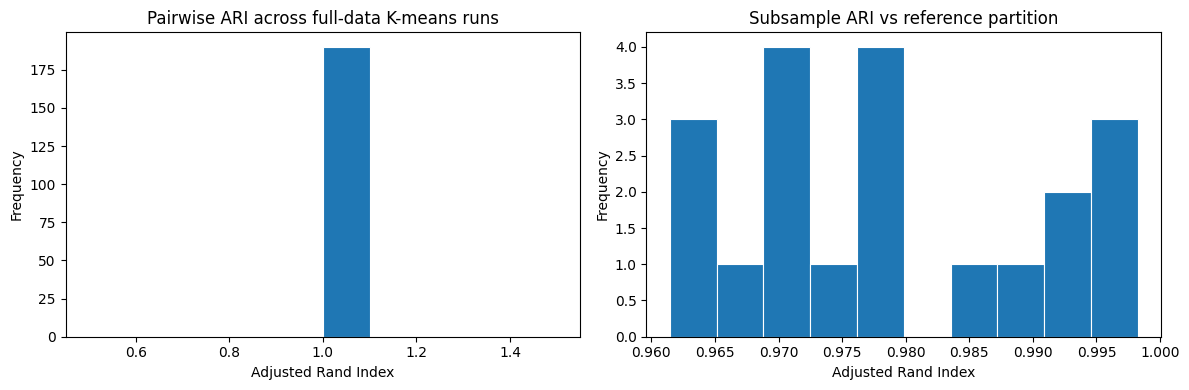

In [98]:
RUN_STABILITY_CHECK = True
STABILITY_N_RUNS = 20
STABILITY_SUBSAMPLE_FRAC = 0.80
STABILITY_K = 4

# Function: pairwise_ari_summary
# This function takes a list of clustering label arrays (from multiple runs of the same clustering algorithm) and computes the pairwise Adjusted Rand Index (ARI) between each pair of runs to quantify the similarity of cluster assignments across runs, which is a key metric for assessing the stability of the clustering results. 
def pairwise_ari_summary(label_runs):
    rows = []
    for i in range(len(label_runs)):
        for j in range(i + 1, len(label_runs)):
            rows.append({
                "run_i": i,
                "run_j": j,
                "ari": adjusted_rand_score(label_runs[i], label_runs[j])
            })
    return pd.DataFrame(rows)

# Function: kmeans_stability_analysis
# This function runs KMeans clustering multiple times on the full dataset and on subsampled versions of the dataset to assess the stability of the clustering results. 
# It collects clustering labels and evaluation metrics for each full run, computes pairwise ARI between full runs to quantify consistency, 
# and then runs KMeans on subsamples of the data to compare the cluster assignments against a reference full run using ARI, 
# which helps identify whether the clustering results are robust to sampling variability.

def kmeans_stability_analysis(X_input, k, n_runs=20, subsample_frac=0.80, random_state=42):
    rng = np.random.default_rng(random_state)

    full_run_labels = []
    full_run_metrics = []

    for run in range(n_runs):
        seed = random_state + run
        model = KMeans(n_clusters=k, n_init=50, max_iter=500, random_state=seed)
        labels = model.fit_predict(X_input)
        full_run_labels.append(labels)
        full_run_metrics.append({
            "run": run,
            "random_state": seed,
            "silhouette": silhouette_score(X_input, labels),
            "davies_bouldin": davies_bouldin_score(X_input, labels),
            "calinski_harabasz": calinski_harabasz_score(X_input, labels),
            "inertia": model.inertia_
        })

    full_run_metrics_df = pd.DataFrame(full_run_metrics)
    full_pairwise_ari_df = pairwise_ari_summary(full_run_labels)

    reference_labels = full_run_labels[0]
    subsample_rows = []
    subsample_n = int(np.floor(X_input.shape[0] * subsample_frac))

    for run in range(n_runs):
        sample_idx = np.sort(rng.choice(np.arange(X_input.shape[0]), size=subsample_n, replace=False))
        model = KMeans(n_clusters=k, n_init=50, max_iter=500, random_state=random_state + 100 + run)
        sample_labels = model.fit_predict(X_input[sample_idx])

        subsample_rows.append({
            "run": run,
            "sample_size": subsample_n,
            "ari_vs_reference_on_sample": adjusted_rand_score(reference_labels[sample_idx], sample_labels)
        })

    subsample_df = pd.DataFrame(subsample_rows)

    stability_summary = pd.DataFrame([{
        "k": k,                                                                                     # Number of clusters used in the K-means stability analysis, which is a key parameter that affects the clustering results and is important to report in the summary of the stability analysis.
        "n_runs": n_runs,                                                                           # Number of repeated K-means runs used to assess stability. More runs provide a more robust estimate of how reproducible the clustering solution is under repeated initialization.                  
        "mean_pairwise_ari_full_runs": full_pairwise_ari_df["ari"].mean(),                          # Average Adjusted Rand Index (ARI) across all pairs of runs using the full dataset, which quantifies the overall stability of the clustering solution under repeated runs. Higher mean ARI indicates more stable clustering results.
        "min_pairwise_ari_full_runs": full_pairwise_ari_df["ari"].min(),                            # Minimum ARI observed across all pairs of runs using the full dataset, which indicates the worst-case stability scenario. A low minimum ARI suggests that there may be some runs that produce very different clustering results, even if the average stability is good.
        "mean_subsample_ari_vs_reference": subsample_df["ari_vs_reference_on_sample"].mean(),       # Average ARI between the clustering solution obtained on subsampled data and the reference partition from the full data runs, which assesses how well the clustering solution generalizes to different subsets of the data. Higher mean ARI indicates that the clustering solution is more robust to changes in the data.
        "min_subsample_ari_vs_reference": subsample_df["ari_vs_reference_on_sample"].min(),         # Minimum ARI observed between the subsampled clustering solutions and the reference partition, which indicates the worst-case generalization scenario. A low minimum ARI suggests that there may be some subsets of the data for which the clustering solution does not align well with the reference partition, even if the average generalization is good.
        "silhouette_mean_across_runs": full_run_metrics_df["silhouette"].mean(),                    # Mean silhouette score across all K-means runs using the full dataset, which provides an overall measure of how well-separated the clusters are on average. Higher mean silhouette indicates that clusters are more distinct and well-formed on average.
        "silhouette_std_across_runs": full_run_metrics_df["silhouette"].std(),                      # Standard deviation of the silhouette score across all K-means runs using the full dataset, which provides a measure of the variability in cluster separation across runs. A high standard deviation indicates that some runs produce clusters that are much less well-separated than others, even if the mean silhouette is high.
        "dbi_mean_across_runs": full_run_metrics_df["davies_bouldin"].mean(),                       # Mean Davies-Bouldin index across all K-means runs using the full dataset, which provides an overall measure of cluster compactness and separation on average. Lower mean DBI indicates that clusters are more compact and better separated on average.
        "dbi_std_across_runs": full_run_metrics_df["davies_bouldin"].std()                          # Standard deviation of the Davies-Bouldin index across all K-means runs using the full dataset, which provides a measure of the variability in cluster compactness and separation across runs. A high standard deviation indicates that some runs produce clusters that are much less compact or less well-separated than others, even if the mean DBI is low.
    }]).round(3)

    return stability_summary, full_run_metrics_df, full_pairwise_ari_df, subsample_df

if RUN_STABILITY_CHECK:
    stability_summary_df, stability_runs_df, stability_pairwise_ari_df, stability_subsample_df = kmeans_stability_analysis(
        X_cluster,
        k=STABILITY_K,
        n_runs=STABILITY_N_RUNS,
        subsample_frac=STABILITY_SUBSAMPLE_FRAC,
        random_state=RANDOM_STATE
    )
    print("K-means stability summary:")
    show_table(stability_summary_df, "kmeans_stability_summary", index=False)

    print("Run-level metric variation:")
    show_table(stability_runs_df.head(10), "kmeans_stability_run_metrics_head10", index=False)

    print("Pairwise ARI across full-data runs:")
    show_table(stability_pairwise_ari_df.head(10), "kmeans_stability_pairwise_ari_head10", index=False)

    print("Subsample agreement against the reference partition:")
    show_table(stability_subsample_df.head(10), "kmeans_stability_subsample_ari_head10", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(stability_pairwise_ari_df["ari"], bins=10, edgecolor="white", linewidth=0.8)
    axes[0].set_title("Pairwise ARI across full-data K-means runs")
    axes[0].set_xlabel("Adjusted Rand Index")
    axes[0].set_ylabel("Frequency")

    axes[1].hist(stability_subsample_df["ari_vs_reference_on_sample"], bins=10, edgecolor="white", linewidth=0.8)
    axes[1].set_title("Subsample ARI vs reference partition")
    axes[1].set_xlabel("Adjusted Rand Index")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    save_fig("kmeans_stability_histograms", fig)
    plt.show()

    mean_full_ari = stability_summary_df.loc[0, "mean_pairwise_ari_full_runs"]
    mean_sub_ari = stability_summary_df.loc[0, "mean_subsample_ari_vs_reference"]

**🕵️‍♂️ Interpretation/Notes:**<br>
- The four-cluster solution is highly reproducible across repeated runs.
- The full-run and subsample ARI values are very high, so the final partition is not being driven by random initialization.
- This strengthens the case for using **K-means (k = 4)** as the final stakeholder-facing model.


## 8. DBSCAN Diagnostic and Final K-means Model

This section does two things:
1. Keeps DBSCAN as a diagnostic view of the data structure,
2. Uses K-means with k = 4 as the final stakeholder-facing segmentation.

In [99]:
FINAL_MODEL_STRATEGY = "DBSCAN diagnostic + KMeans(k=4)"
FINAL_KMEANS_K = 4

# Identify the previously computed K-means result that matches the final chosen k
matched_kmeans = [
    r for r in kmeans_results
    if r["algorithm"] == "KMeans" and r["params"] == f"k={FINAL_KMEANS_K}"
]

# There should be exactly one previously computed K-means result with k=4
if len(matched_kmeans) != 1:
    raise ValueError("Expected exactly one KMeans result with k=4.")

# Refit a clean final K-means model for downstream prediction and transfer testing
final_kmeans_model = KMeans(n_clusters=FINAL_KMEANS_K, n_init=50, max_iter=500, random_state=RANDOM_STATE)
final_labels = final_kmeans_model.fit_predict(X_cluster)

final_result = evaluate_clustering(X_cluster, final_labels, algorithm_name="KMeans")
final_result.update({
    "params": f"k={FINAL_KMEANS_K}",
    "model_object": final_kmeans_model,
    "labels": final_labels
})
final_result_summary = result_to_row(final_result)

# Display the diagnostic DBSCAN result that is being retained for outlier/extreme-tract context, as well as the final K-means model that is being used for interpretation and stakeholder recommendations, including their evaluation metrics and parameters, to provide transparency about the chosen models and their performance characteristics.
print("DBSCAN diagnostic result used for outlier / extreme-tract context:")
show_table(pd.DataFrame([dbscan_diagnostic_summary]), "final_dbscan_diagnostic_summary", index=False)

# Display the final K-means model that is being used for interpretation and stakeholder recommendations, including its evaluation metrics and parameters, to provide transparency about the chosen model and its performance characteristics.
print("\nFinal K-means model used for interpretation and stakeholder recommendations:")
show_table(pd.DataFrame([final_result_summary]), "final_kmeans_model_summary", index=False)

# Record the final algorithm and parameters for downstream use and reporting, which can be referenced in the interpretation and recommendations to stakeholders, as well as in any future analysis or transfer testing that uses the final model.
FINAL_ALGO = final_result["algorithm"]
FINAL_PARAMS = final_result["params"]

# Create a copy of the original dataframe and append the DBSCAN diagnostic labels and the final K-means cluster assignments for downstream analysis, reporting, and any transfer testing that may be performed using the final model.
df_model = df.copy()
df_model["dbscan_diagnostic_label"] = dbscan_diagnostic_labels
df_model["cluster"] = final_labels

# Create a table showing the size of each cluster in the final K-means model to provide insight into the distribution of observations across the clusters, which can inform interpretation and stakeholder recommendations based on the relative sizes of the segments identified by the final model.
cluster_size_df = df_model["cluster"].value_counts(dropna=False).sort_index().to_frame("count")

# Display the cluster size table to provide a quick view of how many observations fall into each of the final K-means clusters, which can help stakeholders understand the relative prevalence of each segment identified by the model.
print("Final model selected:")
print(f"Strategy: {FINAL_MODEL_STRATEGY}")
print(f"Algorithm: {FINAL_ALGO}")
print(f"Parameters: {FINAL_PARAMS}")
show_table(cluster_size_df, "final_kmeans_cluster_sizes", index=True)


DBSCAN diagnostic result used for outlier / extreme-tract context:


,algorithm,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_pct,min_cluster_size,max_cluster_size,balance_ratio,params
0,DBSCAN,2,0.590259,0.305855,55.646423,2.455494,5,3173,0.001576,"eps=1.0, min_samples=5"


Saved table: outputs/tables/final_dbscan_diagnostic_summary.csv

Final K-means model used for interpretation and stakeholder recommendations:


,algorithm,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_pct,min_cluster_size,max_cluster_size,balance_ratio,params
0,KMeans,4,0.39912,0.877678,2956.945483,0.0,405,1269,0.319149,k=4


Saved table: outputs/tables/final_kmeans_model_summary.csv
Final model selected:
Strategy: DBSCAN diagnostic + KMeans(k=4)
Algorithm: KMeans
Parameters: k=4


,count
cluster,
0,1091
1,405
2,1269
3,493


Saved table: outputs/tables/final_kmeans_cluster_sizes.csv


PosixPath('/workspaces/ToU-Clustering/outputs/tables/final_kmeans_cluster_sizes.csv')

**🕵️‍♂️ Interpretation/Notes:**<br>
- DBSCAN is kept as a **diagnostic** because its best result highlights one dense core plus a small set of more extreme tracts.
- K-means with k = 4 is used as the final model because it produces a more balanced segmentation for interpretation and action.
- The final K-means metrics are not perfect, but they are strong enough for a practical tract-level segmentation, especially given the overlap expected in public-health indicators.
- The stability check also supports this choice, with very high agreement across repeated runs and subsamples.

## 9. Cluster Visualization

This section uses several visual formats to show cluster structure and cluster characteristics:
- PCA scatter
- Cluster-size chart
- Standardized profile table
- Heatmap
- t-SNE
- Dentogram

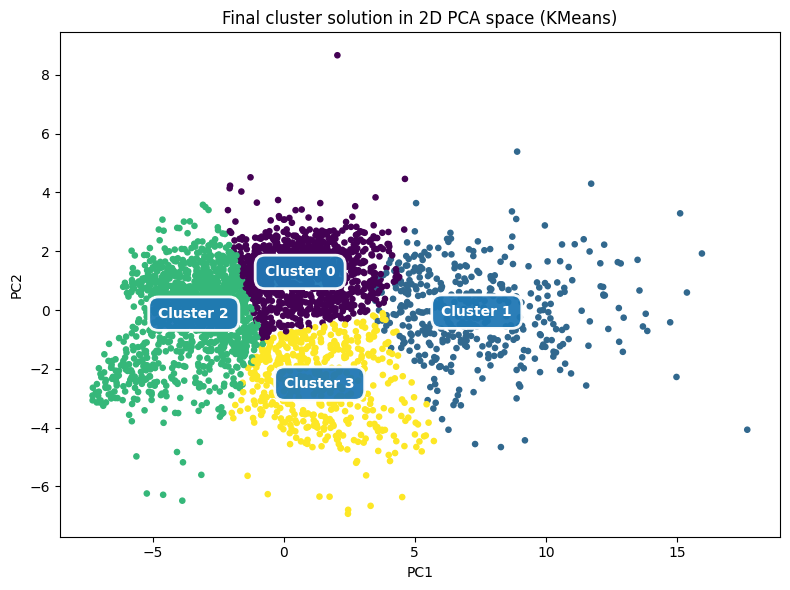

In [100]:
# 2D PCA scatter
viz_pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = viz_pca.fit_transform(X_scaled)

# Create a scatter plot of the final cluster solution in the 2D PCA space, coloring points by their assigned cluster labels, and annotate each cluster with its ID at the centroid to visually assess the separation and structure of the clusters in a reduced dimensionality space.
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=final_labels, s=14)

# Annotate each cluster with its ID at the centroid
for cluster_id in np.unique(final_labels):
    mask = final_labels == cluster_id
    cx, cy = X_2d[mask, 0].mean(), X_2d[mask, 1].mean()
    ax.annotate(
        f"Cluster {cluster_id}",
        xy=(cx, cy),
        fontsize=10,
        fontweight="bold",
        color="white",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.7", fc="#1f77b4", ec="white", lw=2, alpha=0.95),
    )

# Set axis labels and title for the PCA scatter plot, adjust layout, save the figure, and display it to provide a visual summary of the final clustering solution in the reduced 2D PCA space.
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Final cluster solution in 2D PCA space ({FINAL_ALGO})")
plt.tight_layout()
save_fig("final_cluster_solution_pca_scatter")
plt.show()

**🕵️‍♂️ Interpretation/Notes:**<br>
- The PCA scatter shows the final four-cluster solution in two dimensions.
- Separation is strongest at the ends of the distribution, while the middle clusters still overlap.
- This pattern is consistent with a tract dataset shaped by a broad burden gradient plus additional internal variation.

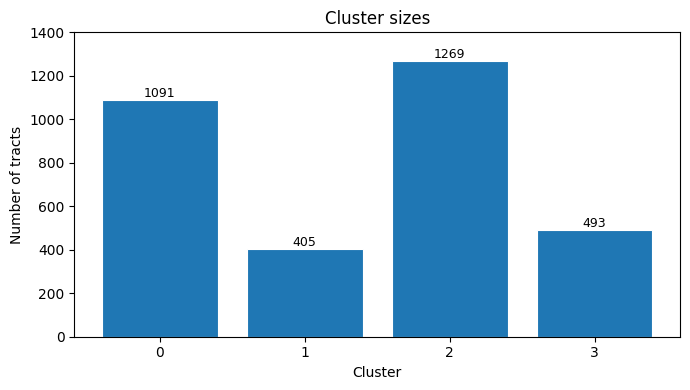

,tract_count
0,1091
1,405
2,1269
3,493


Saved table: outputs/tables/final_cluster_counts.csv


PosixPath('/workspaces/ToU-Clustering/outputs/tables/final_cluster_counts.csv')

In [101]:
# Cluster size chart
cluster_counts = pd.Series(final_labels).value_counts().sort_index()

plt.figure(figsize=(7, 4))
bars = plt.bar(cluster_counts.index.astype(str), cluster_counts.values, edgecolor="white", linewidth=0.8)
plt.xlabel("Cluster")
plt.ylabel("Number of tracts")
plt.title("Cluster sizes")
plt.ylim(0, 1400)

# Add count labels on top of each bar for readability.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
save_fig("final_cluster_sizes")
plt.show()

show_table(cluster_counts.to_frame("tract_count"), "final_cluster_counts", index=True)

In [102]:
# Cluster means in standardized feature space
cluster_profile = X_scaled_df.copy()
cluster_profile["cluster"] = final_labels

cluster_means = cluster_profile.groupby("cluster")[feature_cols_final].mean()
show_table(cluster_means.round(2), "cluster_feature_profiles_standardized", index=True)


,TEETHLOST_CrudePrev,ACCESS2_CrudePrev,BPHIGH_CrudePrev,CHECKUP_CrudePrev,CASTHMA_CrudePrev,CHD_CrudePrev,DIABETES_CrudePrev,COPD_CrudePrev,LPA_CrudePrev,OBESITY_CrudePrev,MHLTH_CrudePrev,CSMOKING_CrudePrev,PHLTH_CrudePrev,GHLTH_CrudePrev,SLEEP_CrudePrev,STROKE_CrudePrev,FOODSTAMP_CrudePrev,HOUSINSECU_CrudePrev,LACKTRPT_CrudePrev,EMOTIONSPT_CrudePrev
cluster,,,,,,,,,,,,,,,,,,,,
0,0.01,-0.32,0.56,0.42,0.25,0.71,0.20,0.57,0.09,0.37,0.18,0.32,0.42,0.04,-0.07,0.35,-0.19,-0.31,-0.26,-0.22
1,1.87,0.84,1.48,0.70,1.92,1.00,1.87,1.45,1.69,1.58,1.47,1.67,1.47,1.81,1.92,1.85,2.11,1.90,1.97,1.76
2,-0.77,-0.60,-0.75,-0.11,-0.71,-0.76,-0.82,-0.84,-0.91,-0.89,-0.80,-0.88,-0.96,-0.89,-0.74,-0.79,-0.71,-0.68,-0.69,-0.70
3,0.42,1.56,-0.52,-1.22,-0.31,-0.43,0.15,-0.30,0.77,0.18,0.45,0.19,0.34,0.70,0.48,-0.27,0.52,0.87,0.71,0.84


Saved table: outputs/tables/cluster_feature_profiles_standardized.csv


PosixPath('/workspaces/ToU-Clustering/outputs/tables/cluster_feature_profiles_standardized.csv')

**🕵️‍♂️ Interpretation/Notes:**<br>
- Cluster 1 has the highest overall standardized burden across the selected features.
- Cluster 2 acts as the lowest-burden comparison profile.
- The middle clusters matter because they show that tracts differ not only by severity, but also by the mix of burden, access, and prevention patterns.

Heatmap:
A heatmap diagram should make the cluster characteristics easier to compare than the scatter plot alone. High levels, marked in red, will be above average burden while low levels, marked in blue, will be below average burden.

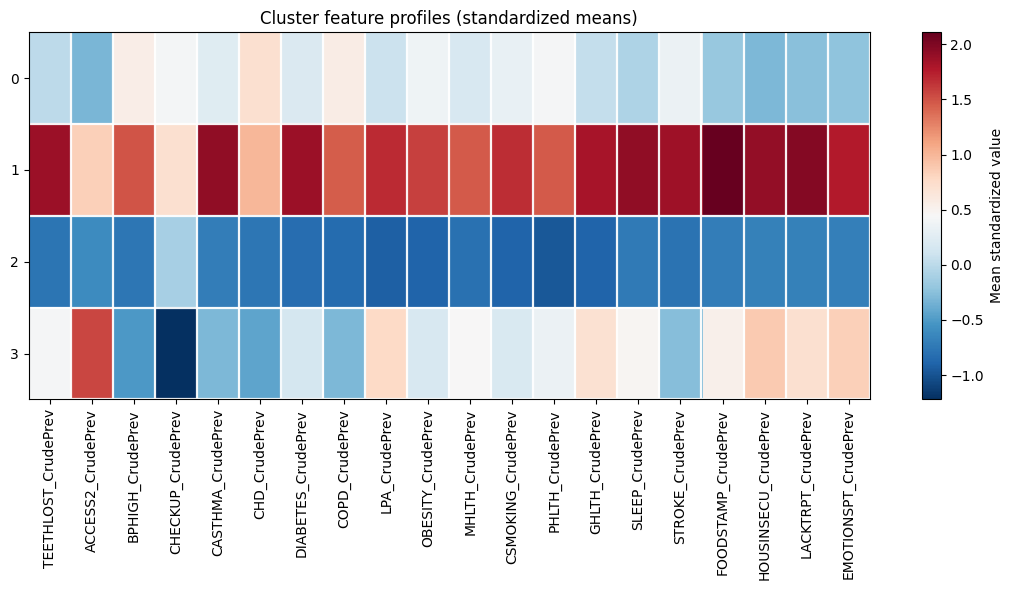

In [103]:
# Heatmap of cluster feature profiles
plt.figure(figsize=(max(10, len(feature_cols_final) * 0.55), 6))
im = plt.imshow(cluster_means.values, aspect="auto", cmap="RdBu_r")
plt.colorbar(im, label="Mean standardized value")
plt.xticks(range(len(feature_cols_final)), feature_cols_final, rotation=90)
plt.yticks(range(len(cluster_means.index)), cluster_means.index)

# Add white borders around each matrix cell for readability.
for x in np.arange(0.5, len(feature_cols_final), 1):
    plt.axvline(x=x, color="white", linewidth=1.6, alpha=0.95)
for y in np.arange(0.5, len(cluster_means.index), 1):
    plt.axhline(y=y, color="white", linewidth=1.6, alpha=0.95)

plt.title("Cluster feature profiles (standardized means)")
plt.tight_layout()
save_fig("cluster_feature_profiles_heatmap")
plt.show()

**🕵️‍♂️ Interpretation/Notes:**<br>
- This is one of the strongest visuals for the final impact brief because it shows what separates the clusters feature by feature.
- The heatmap makes it easier to see that all four clusters have distinct patterns, even when some of the profiles are closer to each other than the extreme groups.
- This figure should be used alongside the cluster summary table because it connects the technical output to the final narrative.

**t-SNE projection on a sample for an additional cluster-structure view**
It should help provide a visual check on the local neighborhood structure of the clusters, which can complement the PCA scatter and heatmap by showing how well the clusters are separated in a way that captures local relationships. However, t-SNE is not used as the primary basis for interpretation due to its sensitivity to parameters and potential for distortion, so it is presented as supporting evidence rather than the main visual for interpreting the final clusters.

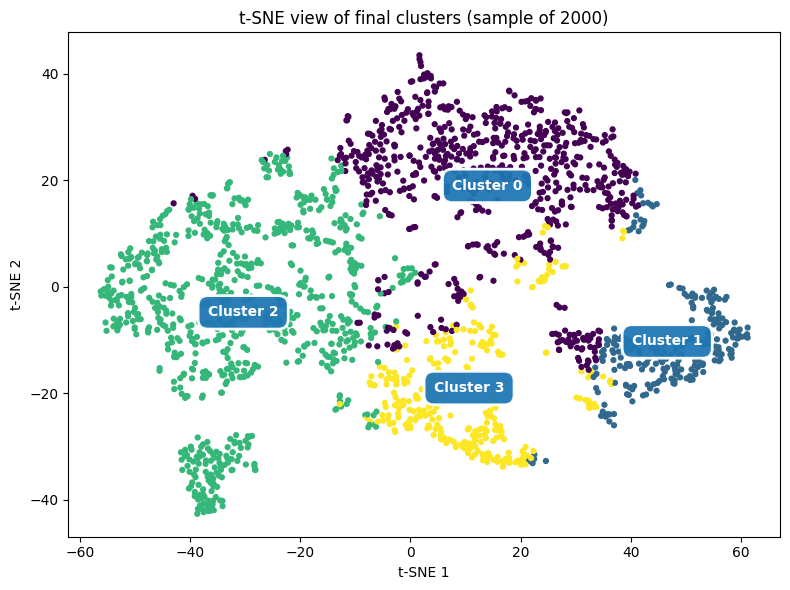

In [104]:
# t-SNE visualization of final clusters
TSNE_SAMPLE_SIZE = min(2000, X_scaled.shape[0])

# Only run t-SNE if the dataset is large enough to provide a meaningful visualization, as t-SNE can be misleading with very small datasets and may not provide additional insight beyond the PCA scatter and heatmap for the capstone visuals.
if X_scaled.shape[0] > 50:
    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(np.arange(X_scaled.shape[0]), size=TSNE_SAMPLE_SIZE, replace=False)
    X_tsne_input = X_scaled[sample_idx]
    y_tsne = np.array(final_labels)[sample_idx]

    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", learning_rate="auto", perplexity=30)
    X_tsne = tsne.fit_transform(X_tsne_input)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_tsne, s=12)

    # Annotate each cluster with its ID at the centroid in t-SNE space.
    for cluster_id in np.unique(y_tsne):
        mask = y_tsne == cluster_id
        cx, cy = X_tsne[mask, 0].mean(), X_tsne[mask, 1].mean()
        plt.annotate(
            f"Cluster {cluster_id}",
            xy=(cx, cy),
            fontsize=10,
            fontweight="bold",
            color="white",
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.7", fc="#1f77b4", ec="white", lw=2, alpha=0.95),
        )

    plt.title(f"t-SNE view of final clusters (sample of {TSNE_SAMPLE_SIZE})")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    save_fig("tsne_view_final_clusters")
    plt.show()

**🕵️‍♂️ Interpretation/Notes:**<br>
- The t-SNE view shows overlap near the center of the data.
- This suggests that the tract profiles are not perfectly separated in low-dimensional space, which is expected for real public-health data.
- Even so, the figure still supports the idea that the final solution is capturing structured differences rather than random noise.

Dendrogram on a sample for readability:<br>
The dendrogram can be very difficult to read with a large number of observations, so a random sample is used for visualization. This is included as supporting evidence that the tract structure can be viewed in more than one way, but the K-means visuals are usually clearer than the dendrogram for stakeholder communication.

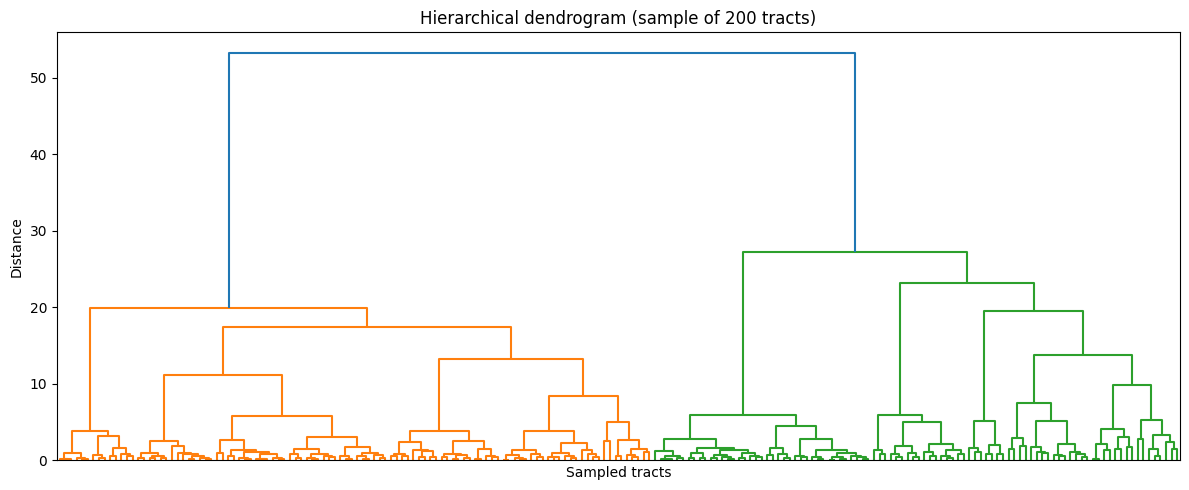

In [105]:
# The dendrogram can help identify whether there are clear hierarchical relationships between the observations and clusters, and can be a useful diagnostic tool for understanding the structure of the data, even if the final clustering solution is based on K-means.
if SCIPY_AVAILABLE:

    sample_n = min(200, X_cluster.shape[0])                                                         # Number of observations to sample for hierarchical clustering and dendrogram visualization, which is set to a maximum of 200 to ensure that the dendrogram remains readable and provides meaningful insights into the hierarchical relationships between the tracts without being overwhelmed by too many observations.
    sample_idx = np.random.choice(np.arange(X_cluster.shape[0]), size=sample_n, replace=False)      # Randomly sample indices for the subset of observations to use in hierarchical clustering and dendrogram visualization, which allows for a representative view of the hierarchical structure while keeping the visualization manageable and interpretable.
    Z = linkage(X_cluster[sample_idx], method="ward")                                               # Compute the hierarchical clustering linkage matrix for the sampled subset of observations using Ward's method, which is a common approach for hierarchical clustering that minimizes the variance within clusters and can help reveal the hierarchical relationships between the tracts based on their feature similarities.

    # Plot the hierarchical dendrogram for the sampled subset of observations to visualize the hierarchical relationships between the tracts, which can provide additional context for understanding the clustering structure and may reveal insights about how the clusters relate to each other in terms of their feature similarities.
    plt.figure(figsize=(12, 5))
    dendrogram(Z, no_labels=True, color_threshold=None)
    plt.title(f"Hierarchical dendrogram (sample of {sample_n} tracts)")
    plt.xlabel("Sampled tracts")
    plt.ylabel("Distance")
    plt.tight_layout()
    save_fig("hierarchical_dendrogram_sample")
    plt.show()

**🕵️‍♂️ Interpretation/Notes:**<br> 
- The dendrogram indicates a nested clustering structure, with two broad tract groupings at the highest level and additional substructure within one of those groups. 
- The final 4-cluster KMeans solution in PCA space is consistent with this pattern: one cluster is clearly separated on the left side of PC1, another is separated on the right, and two additional clusters divide the central region along PC2.

Trying to compare the top-level split from hierarchical clustering with the final K-means clusters to understand how the hierarchical structure relates to the final clustering solution, which can provide insights into whether the K-means clusters align with natural groupings in the data as revealed by the hierarchical dendrogram, even though they are based on different clustering principles.

Contingency table: Hierarchical (2 clusters) vs KMeans (4 clusters)
kmeans4    0    1     2    3
hier2                       
0        803  405     0  444
1        288    0  1269   49

Row percentages
kmeans4      0      1     2      3
hier2                             
0        0.486  0.245  0.00  0.269
1        0.179  0.000  0.79  0.031

Column percentages
kmeans4      0    1    2      3
hier2                          
0        0.736  1.0  0.0  0.901
1        0.264  0.0  1.0  0.099


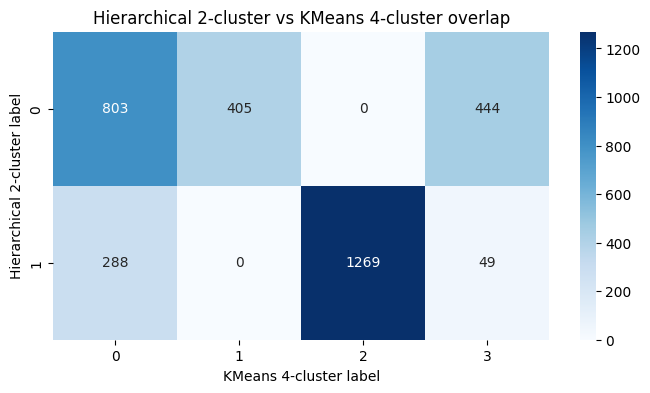

Adjusted Rand Index (ARI): 0.413
Normalized Mutual Information (NMI): 0.457


In [106]:
# Fit a 2-cluster agglomerative model to capture the top-level dendrogram split
hier2_model = AgglomerativeClustering(n_clusters=2, linkage="ward")
hier2_labels = hier2_model.fit_predict(X_cluster)

# Use the final K-means 4-cluster labels from the previously fitted model
kmeans4_labels = final_labels

comparison_df = pd.DataFrame({
    "hier2": hier2_labels,
    "kmeans4": kmeans4_labels
})

# Contingency table
ct = pd.crosstab(comparison_df["hier2"], comparison_df["kmeans4"])
print("Contingency table: Hierarchical (2 clusters) vs KMeans (4 clusters)")
print(ct)

# Row percentages: within each hierarchical cluster, how the KMeans clusters are distributed
ct_row_pct = ct.div(ct.sum(axis=1), axis=0).round(3)
print("\nRow percentages")
print(ct_row_pct)

# Column percentages: within each KMeans cluster, how the hierarchical groups are distributed
ct_col_pct = ct.div(ct.sum(axis=0), axis=1).round(3)
print("\nColumn percentages")
print(ct_col_pct)

# Heatmap for easier reading
plt.figure(figsize=(8, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Hierarchical 2-cluster vs KMeans 4-cluster overlap")
plt.xlabel("KMeans 4-cluster label")
plt.ylabel("Hierarchical 2-cluster label")
plt.show()

# Agreement metrics (valid even when number of clusters differs)
ari = adjusted_rand_score(comparison_df["hier2"], comparison_df["kmeans4"])
nmi = normalized_mutual_info_score(comparison_df["hier2"], comparison_df["kmeans4"])

print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi:.3f}")

**🕵️‍♂️ Interpretation/Notes:**<br> 

- The dendrogram suggests one broad split in the Illinois tracts, with additional structure inside that split.
- The contingency table shows that the final K-means solution is nested inside this broader hierarchical pattern.
- In practice, this means the four-cluster solution is breaking a simpler two-group structure into more detailed and useful tract profiles.

## 10. Cluster Characteristics, Significance, and Actionability

This section explains what each final cluster means in practical terms. 

The focus is on:
1. Key distinguishing features
2. Type of tract profile each cluster represents
3. Potential impact and actions

### 10.1. Cluster characteristics

Helper functions to identify distinguishing features for each cluster.


In [107]:
# Function: top_features_per_cluster
# This helper function identifies the top distinguishing features for each cluster by comparing the mean feature values of each cluster to the overall mean across all clusters, and returns a DataFrame that includes the top features that differ the most from the overall mean in either direction, as well as the top features that are highest and lowest for each cluster, along with a signed summary that indicates whether the top features are higher or lower than the overall mean for that cluster. This information can be used to write plain-language summaries of the clusters and to inform stakeholder recommendations based on the most distinctive characteristics of each segment.   
def top_features_per_cluster(cluster_means_df, top_n=5):
    rows = []
    overall = cluster_means_df.mean(axis=0)

    for cluster_id in cluster_means_df.index:
        diffs = cluster_means_df.loc[cluster_id] - overall
        ordered = diffs.abs().sort_values(ascending=False).index.tolist()

        top_abs = ordered[:top_n]
        top_high = diffs.sort_values(ascending=False).head(top_n).index.tolist()
        top_low = diffs.sort_values(ascending=True).head(top_n).index.tolist()

        rows.append({
            "cluster": cluster_id,                                          # Cluster ID for which the top distinguishing features are being identified
            "top_features_any_direction": top_abs,                          # List of the top features that differ the most from the overall mean for this cluster (regardless of whether they are higher or lower)
            "top_high_features": top_high,                                  # List of the top features that are higher than the overall mean for this cluster
            "top_low_features": top_low                                     # List of the top features that are lower than the overall mean for this cluster

        })

    return pd.DataFrame(rows)

# Use the top_features_per_cluster function to identify the top distinguishing features for each cluster based on the standardized mean feature values, and display the results in a table format to provide insight into which features most clearly differentiate each cluster from the overall mean, which can inform interpretation and stakeholder recommendations.
top_feature_df = top_features_per_cluster(cluster_means, top_n=5)
show_table(top_feature_df, "cluster_top_features", index=False)

,cluster,top_features_any_direction,top_high_features,top_low_features
0,0,"[HOUSINSECU_CrudePrev, LACKTRPT_CrudePrev, ACCESS2_CrudePrev, EMOTIONSPT_CrudePrev, FOODSTAMP_CrudePrev]","[CHD_CrudePrev, CHECKUP_CrudePrev, BPHIGH_CrudePrev, COPD_CrudePrev, PHLTH_CrudePrev]","[HOUSINSECU_CrudePrev, LACKTRPT_CrudePrev, ACCESS2_CrudePrev, EMOTIONSPT_CrudePrev, FOODSTAMP_CrudePrev]"
1,1,"[FOODSTAMP_CrudePrev, CASTHMA_CrudePrev, STROKE_CrudePrev, LACKTRPT_CrudePrev, DIABETES_CrudePrev]","[FOODSTAMP_CrudePrev, CASTHMA_CrudePrev, STROKE_CrudePrev, LACKTRPT_CrudePrev, DIABETES_CrudePrev]","[ACCESS2_CrudePrev, CHECKUP_CrudePrev, CHD_CrudePrev, MHLTH_CrudePrev, PHLTH_CrudePrev]"
2,2,"[LPA_CrudePrev, GHLTH_CrudePrev, PHLTH_CrudePrev, CSMOKING_CrudePrev, OBESITY_CrudePrev]","[CHECKUP_CrudePrev, CHD_CrudePrev, BPHIGH_CrudePrev, ACCESS2_CrudePrev, CASTHMA_CrudePrev]","[LPA_CrudePrev, GHLTH_CrudePrev, PHLTH_CrudePrev, CSMOKING_CrudePrev, OBESITY_CrudePrev]"
3,3,"[ACCESS2_CrudePrev, CHECKUP_CrudePrev, BPHIGH_CrudePrev, CASTHMA_CrudePrev, CHD_CrudePrev]","[ACCESS2_CrudePrev, HOUSINSECU_CrudePrev, EMOTIONSPT_CrudePrev, LPA_CrudePrev, GHLTH_CrudePrev]","[CHECKUP_CrudePrev, BPHIGH_CrudePrev, CASTHMA_CrudePrev, CHD_CrudePrev, STROKE_CrudePrev]"


Saved table: outputs/tables/cluster_top_features.csv


PosixPath('/workspaces/ToU-Clustering/outputs/tables/cluster_top_features.csv')

In [108]:
# Detailed per-cluster ranked differences from the overall mean
cluster_rank_tables = {}
overall_mean = cluster_means.mean(axis=0)

for cluster_id in cluster_means.index:
    diffs = (cluster_means.loc[cluster_id] - overall_mean).sort_values(key=lambda s: s.abs(), ascending=False)
    cluster_rank_tables[cluster_id] = diffs.to_frame("difference_from_overall_mean")
    print(f"\nCluster {cluster_id}")
    show_table(cluster_rank_tables[cluster_id].head(10), f"cluster_{cluster_id}_top_differences", index=True)


Cluster 0


,difference_from_overall_mean
HOUSINSECU_CrudePrev,-0.756167
LACKTRPT_CrudePrev,-0.692166
ACCESS2_CrudePrev,-0.688691
EMOTIONSPT_CrudePrev,-0.641218
FOODSTAMP_CrudePrev,-0.623690
CHD_CrudePrev,0.583781
CHECKUP_CrudePrev,0.469334
SLEEP_CrudePrev,-0.464430
GHLTH_CrudePrev,-0.376058
TEETHLOST_CrudePrev,-0.372567


Saved table: outputs/tables/cluster_0_top_differences.csv

Cluster 1


,difference_from_overall_mean
FOODSTAMP_CrudePrev,1.676043
CASTHMA_CrudePrev,1.635605
STROKE_CrudePrev,1.567309
LACKTRPT_CrudePrev,1.538419
DIABETES_CrudePrev,1.522808
SLEEP_CrudePrev,1.518998
TEETHLOST_CrudePrev,1.487849
HOUSINSECU_CrudePrev,1.455213
GHLTH_CrudePrev,1.396372
CSMOKING_CrudePrev,1.349273


Saved table: outputs/tables/cluster_1_top_differences.csv

Cluster 2


,difference_from_overall_mean
LPA_CrudePrev,-1.322779
GHLTH_CrudePrev,-1.304716
PHLTH_CrudePrev,-1.280566
CSMOKING_CrudePrev,-1.208548
OBESITY_CrudePrev,-1.202299
DIABETES_CrudePrev,-1.173086
TEETHLOST_CrudePrev,-1.151371
FOODSTAMP_CrudePrev,-1.142663
SLEEP_CrudePrev,-1.135212
MHLTH_CrudePrev,-1.126150


Saved table: outputs/tables/cluster_2_top_differences.csv

Cluster 3


,difference_from_overall_mean
ACCESS2_CrudePrev,1.185531
CHECKUP_CrudePrev,-1.168505
BPHIGH_CrudePrev,-0.711467
CASTHMA_CrudePrev,-0.598350
CHD_CrudePrev,-0.561739
STROKE_CrudePrev,-0.555288
COPD_CrudePrev,-0.522405
HOUSINSECU_CrudePrev,0.427044
EMOTIONSPT_CrudePrev,0.420163
LPA_CrudePrev,0.361462


Saved table: outputs/tables/cluster_3_top_differences.csv


### 10.2. Star/Radar graphs for each cluster

Shared radar feature order:
['FOODSTAMP_CrudePrev', 'CASTHMA_CrudePrev', 'STROKE_CrudePrev', 'LACKTRPT_CrudePrev', 'DIABETES_CrudePrev', 'SLEEP_CrudePrev', 'TEETHLOST_CrudePrev', 'HOUSINSECU_CrudePrev', 'GHLTH_CrudePrev', 'CSMOKING_CrudePrev', 'EMOTIONSPT_CrudePrev', 'LPA_CrudePrev', 'BPHIGH_CrudePrev', 'PHLTH_CrudePrev', 'OBESITY_CrudePrev', 'COPD_CrudePrev', 'ACCESS2_CrudePrev', 'CHECKUP_CrudePrev', 'MHLTH_CrudePrev', 'CHD_CrudePrev']


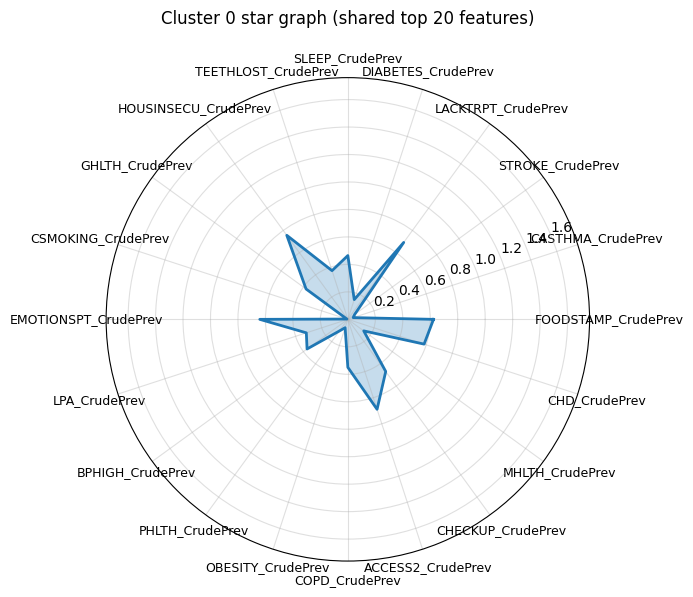

Saved star graph for Cluster 0


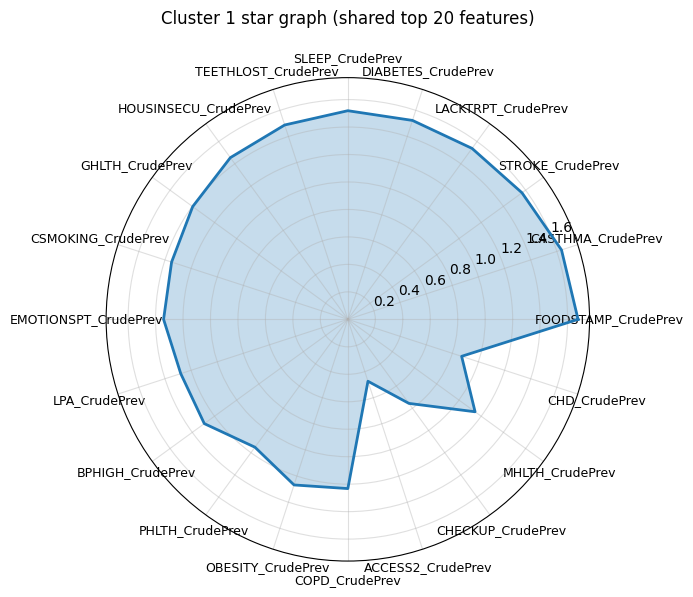

Saved star graph for Cluster 1


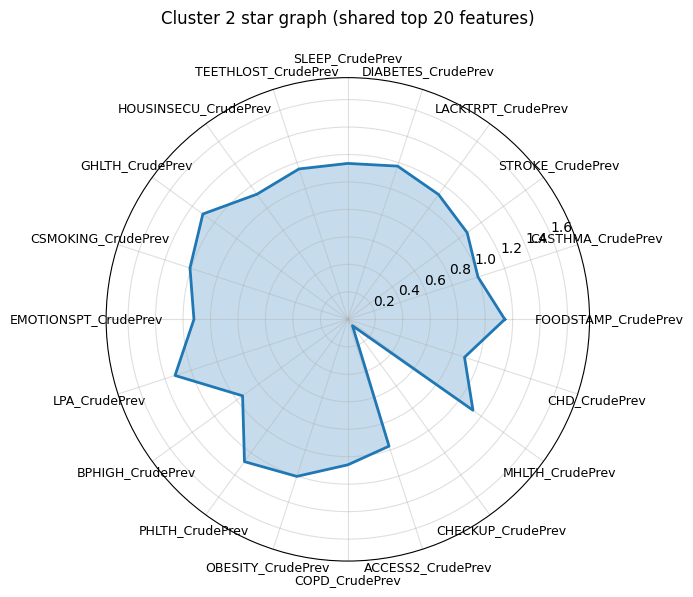

Saved star graph for Cluster 2


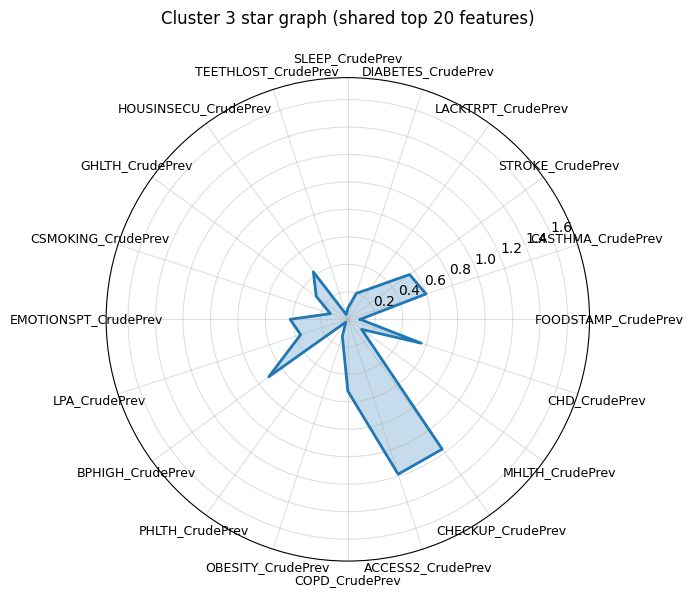

Saved star graph for Cluster 3


In [109]:
# Star (radar) chart for each per-cluster top-difference table
TOP_N_STAR = 20

# Enforce display order 0 -> 3 (or ascending numeric cluster IDs if more are present).
ordered_cluster_ids = sorted(cluster_rank_tables.keys())

# Build one shared feature order across all clusters (top features by max absolute difference).
feature_strength = {}
for cluster_id in ordered_cluster_ids:
    tbl = cluster_rank_tables[cluster_id]
    for feature, diff_val in tbl["difference_from_overall_mean"].items():
        feature_strength[feature] = max(feature_strength.get(feature, 0.0), abs(float(diff_val)))

master_feature_order = [
    f for f, _ in sorted(feature_strength.items(), key=lambda item: item[1], reverse=True)[:TOP_N_STAR]
]

if len(master_feature_order) < 3:
    raise ValueError("Not enough shared features to build radar charts.")

# Use a shared radial scale so all cluster plots are directly comparable.
global_max = max(feature_strength[f] for f in master_feature_order)

print("Shared radar feature order:")
print(master_feature_order)

for cluster_id in ordered_cluster_ids:
    tbl = cluster_rank_tables[cluster_id]

    # Keep the exact same category order for every cluster.
    categories = master_feature_order
    values = [
        abs(float(tbl.loc[f, "difference_from_overall_mean"])) if f in tbl.index else 0.0
        for f in categories
    ]

    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    values += values[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylim(0, global_max * 1.05 if global_max > 0 else 1.0)
    ax.set_title(f"Cluster {cluster_id} star graph (shared top {TOP_N_STAR} features)", pad=20)
    ax.grid(alpha=0.4)

    plt.tight_layout()
    save_fig(f"cluster_{cluster_id}_star_graph_top{TOP_N_STAR}", fig)
    plt.show()

    print(f"Saved star graph for Cluster {cluster_id}")

**🕵️‍♂️ Interpretation/Notes:**<br> 

- Cluster 0 appears to capture tracts with elevated chronic disease but fewer social and access barriers. 
- Cluster 1 represents the highest-burden tracts, combining chronic disease prevalence with economic and transportation hardship. 
- Cluster 2 represents the lowest-burden tracts, with below-average smoking, obesity, inactivity, and poor health indicators. 
- Cluster 3 reflects a different vulnerability pattern characterized more by insecurity, weaker support, and prevention/access gaps than by the highest diagnosed disease burden. 

These results suggest that tract disadvantage is not one-dimensional: some communities are distinguished more by clinical burden, while others are distinguished more by social instability and reduced access to preventive care.


### 10.3. Cluster Interpretation

Characteristics:

<table>
  <thead>
    <tr>
      <th style="text-align: center;">Cluster ID</th>
      <th style="text-align: center;">Cluster profile</th>
      <th style="text-align: center;">Number of tracts</th>
      <th style="text-align: center;">Key distinguishing indicators</th>
      <th style="text-align: center;">Why this cluster matters</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: center;">0</td>
      <td style="text-align: left;">Moderate chronic-burden tracts with lower social vulnerability</td>
      <td style="text-align: center;">1,091</td>
      <td style="text-align: left;"><code>HOUSINSECU_CrudePrev</code>, <code>LACKTRPT_CrudePrev</code>, <code>ACCESS2_CrudePrev</code>, <code>EMOTIONSPT_CrudePrev</code>, <code>FOODSTAMP_CrudePrev</code></td>
      <td style="text-align: left;">This profile suggests a need for steady management, screening, and follow-up rather than crisis-style targeting.</td>
    </tr>
    <tr>
      <td style="text-align: center;">1</td>
      <td style="text-align: left;">High-burden, high-vulnerability tracts</td>
      <td style="text-align: center;">405</td>
      <td style="text-align: left;"><code>FOODSTAMP_CrudePrev</code>, <code>CASTHMA_CrudePrev</code>, <code>STROKE_CrudePrev</code>, <code>LACKTRPT_CrudePrev</code>, <code>DIABETES_CrudePrev</code></td>
      <td style="text-align: left;">This profile combines high chronic disease burden, worse health status, risk behaviors, and material or access stress in the same places. It supports concentrated place-based action.</td>
    </tr>
    <tr>
      <td style="text-align: center;">2</td>
      <td style="text-align: left;">Lower-burden comparison tracts</td>
      <td style="text-align: center;">1,269</td>
      <td style="text-align: left;"><code>LPA_CrudePrev</code>, <code>GHLTH_CrudePrev</code>, <code>PHLTH_CrudePrev</code>, <code>CSMOKING_CrudePrev</code>, <code>OBESITY_CrudePrev</code></td>
      <td style="text-align: left;">This profile provides a useful lower-burden benchmark for comparison, monitoring, and prevention maintenance.</td>
    </tr>
    <tr>
      <td style="text-align: center;">3</td>
      <td style="text-align: left;">Access-challenged prevention-gap tracts</td>
      <td style="text-align: center;">493</td>
      <td style="text-align: left;"><code>ACCESS2_CrudePrev</code>, <code>CHECKUP_CrudePrev</code>, <code>BPHIGH_CrudePrev</code>, <code>CASTHMA_CrudePrev</code>, <code>CHD_CrudePrev</code></td>
      <td style="text-align: left;">This profile suggests that connection to routine care and prevention may be as important as treatment intensity. The gap between access burden and routine checkup patterns matters here.</td>
    </tr>
  </tbody>
</table>

**Cluster 0 — Moderate chronic-burden tracts with lower social vulnerability**  
These tracts show a moderate level of chronic disease burden, especially on indicators such as coronary heart disease, high blood pressure, and related physical-health strain. At the same time, they are relatively lower on housing insecurity, transportation barriers, access problems, emotional support gaps, and food assistance reliance than the more vulnerable clusters. This makes Cluster 0 different from the highest-burden profile: the health burden is still important, but the surrounding social stress appears lower. For stakeholders, this suggests a need for steady screening, chronic disease management, and follow-up care rather than crisis-style targeting.

**Cluster 1 — High-burden, high-vulnerability tracts**  
These tracts show the clearest stacked burden in the final solution. The profile is elevated on poor general health, asthma, stroke, diabetes, smoking, food assistance reliance, and other signals of both health and social strain. This cluster stands out because several risks appear together rather than in isolation. For stakeholders, this is the most urgent place-based priority group and is the strongest candidate for intensive outreach, prevention support, and coordinated community health action.

**Cluster 2 — Lower-burden comparison tracts**  
This is the lowest-burden profile in the final segmentation. These tracts tend to fall below the statewide average on many poor-health, chronic disease, and risk-behavior indicators. The cluster is still important because it provides a useful comparison group for understanding what lower statewide burden looks like. For stakeholders, the main message is maintenance: continue prevention, monitor for change, and use this group as a reference point when evaluating interventions in higher-burden areas.

**Cluster 3 — Access-challenged prevention-gap tracts**  
This cluster is important because it is not simply the highest-burden or the lowest-burden group. Instead, it stands out more on access and prevention-related differences, including barriers connected to routine care and checkups. Disease burden is present, but the larger issue appears to be weaker connection to preventive services and ongoing care. This makes Cluster 3 especially relevant for care navigation, routine screening, transportation support, and other strategies that strengthen access before burden becomes more severe.

## 11. Stakeholder Action Matrix

Mapping cluster profiles to possible actions:

<table>
  <thead>
    <tr>
      <th style="text-align: center;">Cluster ID</th>
      <th style="text-align: center;">Cluster profile</th>
      <th style="text-align: center;">Priority stakeholders</th>
      <th style="text-align: center;">Suggested action</th>
      <th style="text-align: center;">Evidence from profile</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: center;">0</td>
      <td style="text-align: left;">Moderate chronic-burden tracts</td>
      <td style="text-align: left;">Health departments; clinic networks; prevention teams</td>
      <td style="text-align: left;">Use maintenance-style strategies such as screening, chronic disease follow-up, and behavior-risk reduction before burden deepens.</td>
      <td style="text-align: left;"><code>HOUSINSECU_CrudePrev</code>, <code>LACKTRPT_CrudePrev</code>, <code>ACCESS2_CrudePrev</code>, <code>EMOTIONSPT_CrudePrev</code>, <code>FOODSTAMP_CrudePrev</code></td>
    </tr>
    <tr>
      <td style="text-align: center;">1</td>
      <td style="text-align: left;">High-burden, high-vulnerability tracts</td>
      <td style="text-align: left;">County health departments; community clinics; nonprofit coalitions; equity-focused funders</td>
      <td style="text-align: left;">Target multi-issue interventions that combine chronic disease management, smoking cessation, asthma support, prevention outreach, and social-support partnerships.</td>
      <td style="text-align: left;"><code>FOODSTAMP_CrudePrev</code>, <code>CASTHMA_CrudePrev</code>, <code>STROKE_CrudePrev</code>, <code>LACKTRPT_CrudePrev</code>, <code>DIABETES_CrudePrev</code></td>
    </tr>
    <tr>
      <td style="text-align: center;">2</td>
      <td style="text-align: left;">Lower-burden comparison tracts</td>
      <td style="text-align: left;">Public-health planners; prevention teams; monitoring and evaluation teams</td>
      <td style="text-align: left;">Maintain prevention and monitor change over time so lower-burden areas do not drift into higher-need profiles.</td>
      <td style="text-align: left;"><code>LPA_CrudePrev</code>, <code>GHLTH_CrudePrev</code>, <code>PHLTH_CrudePrev</code>, <code>CSMOKING_CrudePrev</code>, <code>OBESITY_CrudePrev</code></td>
    </tr>
    <tr>
      <td style="text-align: center;">3</td>
      <td style="text-align: left;">Access-challenged prevention-gap tracts</td>
      <td style="text-align: left;">Care navigators; community clinics; outreach teams; nonprofit partners</td>
      <td style="text-align: left;">Strengthen preventive care use, care navigation, outreach, and routine screening access in places where access barriers appear more important than the highest disease burden.</td>
      <td style="text-align: left;"><code>ACCESS2_CrudePrev</code>, <code>CHECKUP_CrudePrev</code>, <code>BPHIGH_CrudePrev</code>, <code>CASTHMA_CrudePrev</code>, <code>CHD_CrudePrev</code></td>
    </tr>
  </tbody>
</table>

In [110]:
# Build cluster_summary: top distinguishing features per cluster with tract counts
_tract_counts = pd.Series(final_labels).value_counts().sort_index().rename("tract_count")
cluster_summary = top_feature_df.copy()
cluster_summary["tract_count"] = cluster_summary["cluster"].map(_tract_counts)

# Generating a version of the tables above as a CSV
feature_name_map = (
    feature_selection_rationale_df
    .drop_duplicates(subset=["selected_column"])
    .set_index("selected_column")["concept"]
    .to_dict()
)

# Function: readable_feature_name
# This helper function takes a column name and converts it into a more human-readable format by mapping it to a concept name using the feature_name_map, and then replacing underscores with spaces and removing the word "related" to create a cleaner label for display in tables and charts, which can help stakeholders better understand the features that are driving the cluster profiles without needing to interpret raw column names that may be less intuitive. 
# If a column name is not found in the feature_name_map, it will simply return the original column name with the same formatting applied, ensuring that all features can be displayed in a more readable format even if they are not explicitly mapped to a concept name.
def readable_feature_name(col):
    raw = feature_name_map.get(col, col)
    return raw.replace("_", " ").replace("related", "").strip()

# Function: cols_matching
# This helper function takes a list of keywords and returns all column names from cluster_means that contain any of the keywords (case-insensitive). 
# It is used to group columns into thematic categories such as chronic conditions, health behaviors, access, deprivation, and other domains, 
# which are then used to calculate cluster-level burden scores for each domain to summarize the characteristics of each cluster in a more interpretable way.
def cols_matching(keywords):
    return [c for c in cluster_means.columns if any(k in c.upper() for k in keywords)]

# Define thematic groups of features based on keywords in their names to calculate domain-specific burden scores for each cluster, which can help summarize the key characteristics of each cluster in terms of chronic disease burden, health behaviors, access issues, deprivation, health status, and social support gaps, providing a more interpretable profile for each segment that can inform stakeholder recommendations.
chronic_cols = cols_matching(["BPHIGH", "CHD", "COPD", "DIABETES", "STROKE", "CASTHMA"])
behavior_cols = cols_matching(["CSMOKING", "LPA", "OBESITY", "SLEEP"])
access_cols = cols_matching(["ACCESS2"])
checkup_cols = cols_matching(["CHECKUP"])
deprivation_cols = cols_matching(["FOODSTAMP", "FOODINSECU", "HOUSINSECU", "SHUTUTILITY", "LACKTRPT"])
health_status_cols = cols_matching(["GHLTH", "PHLTH", "MHLTH", "TEETH"])
support_cols = cols_matching(["EMOTIONSPT", "LONELINESS"])

# Create a new DataFrame that summarizes the domain-specific burden signals for each cluster by taking the mean of the relevant columns for each thematic group defined above. 
cluster_signal_df = pd.DataFrame(index=cluster_means.index)
cluster_signal_df["overall_burden"] = cluster_means.mean(axis=1)
cluster_signal_df["chronic_burden"] = cluster_means[chronic_cols].mean(axis=1) if chronic_cols else 0
cluster_signal_df["behavior_burden"] = cluster_means[behavior_cols].mean(axis=1) if behavior_cols else 0
cluster_signal_df["deprivation_burden"] = cluster_means[deprivation_cols].mean(axis=1) if deprivation_cols else 0
cluster_signal_df["health_status_burden"] = cluster_means[health_status_cols].mean(axis=1) if health_status_cols else 0
cluster_signal_df["support_or_connection_gap"] = cluster_means[support_cols].mean(axis=1) if support_cols else 0
cluster_signal_df["access_gap"] = (
    (cluster_means[access_cols].mean(axis=1) if access_cols else 0)
    - (cluster_means[checkup_cols].mean(axis=1) if checkup_cols else 0)
)

# Identify the clusters with the highest overall burden, lowest overall burden, and highest access gap (among the middle clusters) to inform the labeling and interpretation of the clusters based on their key characteristics, which can help stakeholders understand the relative needs and challenges of each segment and guide targeted recommendations for intervention strategies.
highest_burden_cluster = int(cluster_signal_df["overall_burden"].idxmax())
lowest_burden_cluster = int(cluster_signal_df["overall_burden"].idxmin())
middle_clusters = [c for c in cluster_signal_df.index if c not in [highest_burden_cluster, lowest_burden_cluster]]
highest_access_gap_cluster = int(cluster_signal_df.loc[middle_clusters, "access_gap"].idxmax()) if middle_clusters else None

# Create a mapping of cluster IDs to descriptive labels based on their characteristics, which will be used to provide more interpretable names for each cluster in the summary tables and stakeholder recommendations, helping to communicate the key insights about each segment in a way that is accessible and actionable for stakeholders.
label_map = {}
for cluster_id in cluster_means.index:
    if cluster_id == highest_burden_cluster:
        label_map[cluster_id] = "High-burden, high-vulnerability tracts"
    elif cluster_id == lowest_burden_cluster:
        label_map[cluster_id] = "Lower-burden comparison tracts"
    elif cluster_id == highest_access_gap_cluster:
        label_map[cluster_id] = "Access-challenged prevention-gap tracts"
    else:
        label_map[cluster_id] = "Moderate chronic-burden tracts"

# Mapping:
# Create a mapping from the descriptive cluster labels to explanations of why each cluster matters, which will be used to provide context in the detailed cluster interpretation table so that stakeholders can understand the significance of each profile in terms of public health priorities and intervention planning.

# The explanations in the why_map are designed to highlight the key characteristics of each cluster and their relevance for public health action, such as the need for concentrated place-based interventions in high-burden areas, the importance of improving access to preventive care in access-challenged areas, the value of steady management and screening in moderate-burden areas, and the role of monitoring and prevention maintenance in lower-burden areas to prevent deterioration over time.
why_map = {
    "High-burden, high-vulnerability tracts": "This profile combines high chronic disease burden, worse health status, risk behaviors, and material or access stress in the same places. It supports concentrated place-based action.",
    "Access-challenged prevention-gap tracts": "This profile suggests that connection to routine care and prevention may be as important as treatment intensity. The gap between access burden and routine checkup patterns matters here.",
    "Moderate chronic-burden tracts": "This profile suggests a need for steady management, screening, and follow-up rather than crisis-style targeting.",
    "Lower-burden comparison tracts": "This profile provides a useful lower-burden benchmark for comparison, monitoring, and prevention maintenance."
}

# Create a mapping from the descriptive cluster labels to priority stakeholders and example actions, which will be used to generate a stakeholder-action matrix that provides actionable recommendations for each cluster profile, helping stakeholders understand who should be involved in addressing the needs of each segment and what types of interventions or strategies may be most effective based on the characteristics of the cluster.
stakeholder_map = {
    "High-burden, high-vulnerability tracts": "County health departments; community clinics; nonprofit coalitions; equity-focused funders",
    "Access-challenged prevention-gap tracts": "Care navigators; community clinics; outreach teams; nonprofit partners",
    "Moderate chronic-burden tracts": "Health departments; clinic networks; prevention teams",
    "Lower-burden comparison tracts": "Public-health planners; prevention teams; monitoring and evaluation teams"
}

# The action_map provides example actions for each cluster profile that correspond to the priority stakeholders identified in the stakeholder_map. This mapping will be used to populate the stakeholder-action matrix so that for each cluster profile, stakeholders can see concrete examples of interventions or strategies that are aligned with the characteristics of the cluster and the public health priorities it represents.
action_map = {
    "High-burden, high-vulnerability tracts": "Target multi-issue interventions that combine chronic disease management, smoking cessation, asthma support, prevention outreach, and social-support partnerships.",
    "Access-challenged prevention-gap tracts": "Strengthen preventive care use, care navigation, outreach, and routine screening access in places where access barriers appear more important than the highest disease burden.",
    "Moderate chronic-burden tracts": "Use maintenance-style strategies such as screening, chronic disease follow-up, and behavior-risk reduction before burden deepens.",
    "Lower-burden comparison tracts": "Maintain prevention and monitor change over time so lower-burden areas do not drift into higher-need profiles."
}

# Build a detailed cluster interpretation table that includes the cluster ID, descriptive profile name, tract count, distinguishing features, and an explanation of why this cluster matters, which will provide stakeholders with a comprehensive summary of each cluster's characteristics and significance to inform targeted interventions and resource allocation.
detailed_rows = []
for _, row in cluster_summary.iterrows():
    cluster_id = row["cluster"]
    label = label_map[cluster_id]
    top_features = row["top_features_any_direction"]
    detailed_rows.append({
        "cluster": cluster_id,
        "profile_name": label,
        "tract_count": int(row["tract_count"]),
        "distinguishing_features": top_features,
        "why_this_cluster_matters": why_map[label]
    })

# Create a DataFrame from the detailed cluster interpretation rows and display it in a table format to provide a clear and comprehensive summary of each cluster's profile, including its key characteristics, the number of tracts it contains, the most distinguishing features, and the rationale for why this cluster is important from a public health perspective.
detailed_cluster_interpretation_df = pd.DataFrame(detailed_rows)
show_table(detailed_cluster_interpretation_df, "detailed_cluster_interpretation", index=False)

# Build a stakeholder-action matrix that maps each cluster profile to its priority stakeholders, example actions, and evidence from the distinguishing features, which will provide actionable recommendations for stakeholders based on the characteristics of each cluster, helping to guide targeted interventions and resource allocation that is aligned with the needs of each segment.
action_rows = []
for _, row in detailed_cluster_interpretation_df.iterrows():
    action_rows.append({
        "cluster": row["cluster"],
        "profile_name": row["profile_name"],
        "priority_stakeholders": stakeholder_map[row["profile_name"]],
        "example_action": action_map[row["profile_name"]],
        "evidence_from_profile": row["distinguishing_features"]
    })

# Create a DataFrame from the stakeholder-action rows and display it in a table format to provide stakeholders with clear recommendations for who should be involved in addressing the needs of each cluster profile, what types of actions may be effective, and what evidence from the cluster profiles supports these recommendations.    
stakeholder_action_df = pd.DataFrame(action_rows)
show_table(stakeholder_action_df, "stakeholder_action_matrix", index=False)


,cluster,profile_name,tract_count,distinguishing_features,why_this_cluster_matters
0,0,Moderate chronic-burden tracts,1091,"[HOUSINSECU_CrudePrev, LACKTRPT_CrudePrev, ACCESS2_CrudePrev, EMOTIONSPT_CrudePrev, FOODSTAMP_CrudePrev]","This profile suggests a need for steady management, screening, and follow-up rather than crisis-style targeting."
1,1,"High-burden, high-vulnerability tracts",405,"[FOODSTAMP_CrudePrev, CASTHMA_CrudePrev, STROKE_CrudePrev, LACKTRPT_CrudePrev, DIABETES_CrudePrev]","This profile combines high chronic disease burden, worse health status, risk behaviors, and material or access stress in the same places. It supports concentrated place-based action."
2,2,Lower-burden comparison tracts,1269,"[LPA_CrudePrev, GHLTH_CrudePrev, PHLTH_CrudePrev, CSMOKING_CrudePrev, OBESITY_CrudePrev]","This profile provides a useful lower-burden benchmark for comparison, monitoring, and prevention maintenance."
3,3,Access-challenged prevention-gap tracts,493,"[ACCESS2_CrudePrev, CHECKUP_CrudePrev, BPHIGH_CrudePrev, CASTHMA_CrudePrev, CHD_CrudePrev]",This profile suggests that connection to routine care and prevention may be as important as treatment intensity. The gap between access burden and routine checkup patterns matters here.


Saved table: outputs/tables/detailed_cluster_interpretation.csv


,cluster,profile_name,priority_stakeholders,example_action,evidence_from_profile
0,0,Moderate chronic-burden tracts,Health departments; clinic networks; prevention teams,"Use maintenance-style strategies such as screening, chronic disease follow-up, and behavior-risk reduction before burden deepens.","[HOUSINSECU_CrudePrev, LACKTRPT_CrudePrev, ACCESS2_CrudePrev, EMOTIONSPT_CrudePrev, FOODSTAMP_CrudePrev]"
1,1,"High-burden, high-vulnerability tracts",County health departments; community clinics; nonprofit coalitions; equity-focused funders,"Target multi-issue interventions that combine chronic disease management, smoking cessation, asthma support, prevention outreach, and social-support partnerships.","[FOODSTAMP_CrudePrev, CASTHMA_CrudePrev, STROKE_CrudePrev, LACKTRPT_CrudePrev, DIABETES_CrudePrev]"
2,2,Lower-burden comparison tracts,Public-health planners; prevention teams; monitoring and evaluation teams,Maintain prevention and monitor change over time so lower-burden areas do not drift into higher-need profiles.,"[LPA_CrudePrev, GHLTH_CrudePrev, PHLTH_CrudePrev, CSMOKING_CrudePrev, OBESITY_CrudePrev]"
3,3,Access-challenged prevention-gap tracts,Care navigators; community clinics; outreach teams; nonprofit partners,"Strengthen preventive care use, care navigation, outreach, and routine screening access in places where access barriers appear more important than the highest disease burden.","[ACCESS2_CrudePrev, CHECKUP_CrudePrev, BPHIGH_CrudePrev, CASTHMA_CrudePrev, CHD_CrudePrev]"


Saved table: outputs/tables/stakeholder_action_matrix.csv


PosixPath('/workspaces/ToU-Clustering/outputs/tables/stakeholder_action_matrix.csv')

## 12. Reflection: Framing, Methods & Insights

### 12.1 How the problem framing shaped the analysis

This project uses a health-equity framing rather than a purely technical goal. That framing shaped the feature-selection strategy because the aim was not to maximize the number of available columns, but to build a balanced tract profile using disease burden, prevention, health status, risk behaviors, and selected context measures. It also shaped the choice of clustering methods. Instead of relying on one familiar method, the notebook compares a centroid-based method, a hierarchical method, and a density-based method so that the final choice is grounded in both data structure and practical usefulness.

### 12.2 Strengths and limitations of the methods

Main insights about the methods:

- **K-means** provides a clear and interpretable baseline after scaling and dimensionality reduction.  
- **Agglomerative clustering** provides a useful comparison because it can reveal broad structure and nested grouping patterns.  
- **DBSCAN** adds a density-based view and helps identify whether the data behave like one broad core plus a few extreme tracts, but it is sensitive to parameter choices and can produce highly imbalanced solutions.  

PCA improved efficiency and reduced redundancy, but it also created a trade-off between compact representation and direct feature-level interpretability.

### 12.3 How well the final result matches the goal

The final results align reasonably well with the original objective.

The solution identifies a clear higher-burden tract profile, a lower-burden comparison profile, and intermediate profiles that differ in access, prevention, and chronic disease burden. This means the final segmentation is not just a ranking from worst to best. It also captures useful variation in how burden appears across tracts. The stability section adds another layer of support by showing that the final K-means partition is reproducible across repeated runs and resamples.

### 12.4 Key insights and major challenges

The strongest insight is that Illinois tracts follow a broad burden gradient, but that gradient still contains meaningful nested profiles. The main challenge was high feature redundancy, which made careful preprocessing and model comparison necessary. Another challenge was choosing a final model that balanced metrics and actionability rather than simply selecting the top raw score.

### 12.5 Final reflection

The final segmentation should be treated as a practical planning tool. It is useful for targeting and prioritization, but it is not a causal model and it should always be interpreted alongside local knowledge and stakeholder context.

# Deliverable 3: **Actionable Impact Brief**

## 13. Impact Brief (for Non-Technical Stakeholders)

### 1. Executive Summary

This project grouped Illinois census tracts into community health-equity profiles using CDC PLACES indicators that capture chronic disease burden, health status, prevention, health behaviors, and selected context measures. The final stakeholder-facing result is a **four-profile segmentation** built with **K-means (k = 4)**. A separate **DBSCAN diagnostic** was also run to test whether the data behaved like several balanced dense groups or one broad core with a few extreme cases.

The main result is that Illinois tracts are not all facing the same type of health challenge. More specifically:

- One profile shows stacked burden across chronic disease, poor health, smoking, sleep, and social vulnerability.  
- Another profile is defined more by prevention and access barriers.  
- A third reflects moderate chronic disease burden with lower surrounding social vulnerability.  
- The final profile serves as a lower-burden comparison group.  

The notebook also includes a stability section so the final model choice is supported by more than one metric.

This segmentation can support more precise planning. Instead of sending the same intervention to every tract, stakeholders can use the profiles to decide where intensive support, routine management, prevention access, or maintenance-level public-health work is most appropriate. Figure-style outputs in the notebook, especially the PCA scatter, cluster-size chart, and standardized profile heatmap, support this interpretation.

### 2. Data used

The notebook uses the **CDC PLACES tract-level GIS-friendly dataset** and focuses on Illinois census tracts. The final feature set includes indicators related to:

1. Access and prevention  
2. Chronic disease burden  
3. Self-reported health  
4. Risk behaviors  
5. Selected context measures  

The workflow includes data cleaning, scaling, PCA, clustering-readiness checks, comparison of several algorithms, and a stability check for the final K-means model.

### 3. What the four profiles mean

In simple terms, the final segmentation separates:

- **High-burden, high-vulnerability** tracts  
- **Access-challenged prevention-gap** tracts  
- **Moderate chronic-burden tracts with lower social vulnerability**  
- **Lower-burden comparison** tracts  

These profiles can support more targeted outreach, planning, and funding decisions.

### 4. What DBSCAN added

DBSCAN was not used as the final segmentation because its solutions were too imbalanced for planning. Still, it was useful as a diagnostic because it showed that the statewide pattern includes a broad core plus a smaller set of more extreme tracts.

### 5. Recommendations

1. **Target intensive support** in the highest-burden, highest-vulnerability tracts.  
2. **Strengthen prevention and care navigation** in tracts with larger access gaps.  
3. **Maintain steady chronic disease management** in tracts with moderate burden but lower surrounding social vulnerability.  
4. **Use the lower-burden profile as a comparison group** for monitoring and evaluation.  

### 6. Caveats

- Many features are strongly correlated, so part of the clustering signal reflects a broad burden gradient.  
- The clusters are useful for action, but they are not perfectly separated natural categories.  
- The results should guide deeper review, not replace local knowledge.

## 14. Transfer Test: Applying the Final Model to Another State

This section adds a simple generalization check. The final Illinois-trained preprocessing pipeline and K-means model are applied to a second state to see whether similar tract profiles appear.

This is **not** a full external validation study since we can not assume that conditions are comparable (states differ significantly on multiple factors). It is an exploratory transfer test that asks whether the selected workflow can be reused in another setting and whether the broad cluster patterns are partially reproduced.


,algorithm,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_pct,min_cluster_size,max_cluster_size,balance_ratio,params
0,KMeans transfer from IL to IN,4,0.346752,0.894398,1129.208189,0.0,82,1120,0.073214,"trained_on=IL, predicted_on=IN"


Saved table: outputs/tables/transfer_test_summary.csv


,tract_count
0,1120
1,245
2,238
3,82


Saved table: outputs/tables/transfer_test_cluster_counts.csv


,cluster,IL_share,IN_share
0,0,0.334868,0.664688
1,1,0.124309,0.145401
2,2,0.389503,0.141246
3,3,0.151320,0.048665


Saved table: outputs/tables/transfer_test_cluster_share_comparison.csv


,TEETHLOST_CrudePrev,ACCESS2_CrudePrev,BPHIGH_CrudePrev,CHECKUP_CrudePrev,CASTHMA_CrudePrev,CHD_CrudePrev,DIABETES_CrudePrev,COPD_CrudePrev,LPA_CrudePrev,OBESITY_CrudePrev,MHLTH_CrudePrev,CSMOKING_CrudePrev,PHLTH_CrudePrev,GHLTH_CrudePrev,SLEEP_CrudePrev,STROKE_CrudePrev,FOODSTAMP_CrudePrev,HOUSINSECU_CrudePrev,LACKTRPT_CrudePrev,EMOTIONSPT_CrudePrev
cluster,,,,,,,,,,,,,,,,,,,,
0,0.35,-0.32,0.75,0.71,0.84,0.70,0.31,0.78,0.18,0.53,0.52,0.75,0.55,0.14,0.05,0.15,-0.67,-0.48,-0.34,-0.64
1,2.50,0.86,1.68,0.61,2.23,1.55,1.98,2.26,1.84,1.76,1.95,2.52,2.06,1.96,1.80,1.61,0.84,1.09,1.44,0.75
2,-0.56,-0.77,-0.16,0.70,0.18,-0.56,-0.63,-0.60,-0.95,-0.39,-0.45,-0.57,-0.78,-0.84,-0.55,-0.77,-0.99,-0.87,-0.78,-1.29
3,1.66,0.63,-0.32,-0.96,1.40,-0.54,-0.32,0.29,0.56,0.53,2.27,1.07,0.56,0.70,0.77,-0.49,0.01,0.38,0.91,0.31


Saved table: outputs/tables/transfer_test_cluster_profiles_standardized.csv


,cluster,profile_correlation
0,0,0.881615
1,1,0.307778
2,2,0.586406
3,3,0.474098


Saved table: outputs/tables/transfer_test_profile_similarity.csv


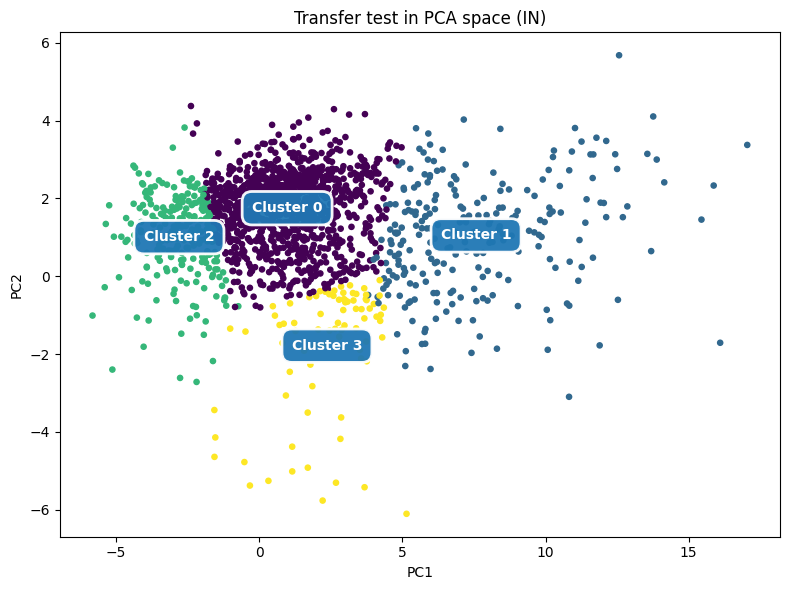

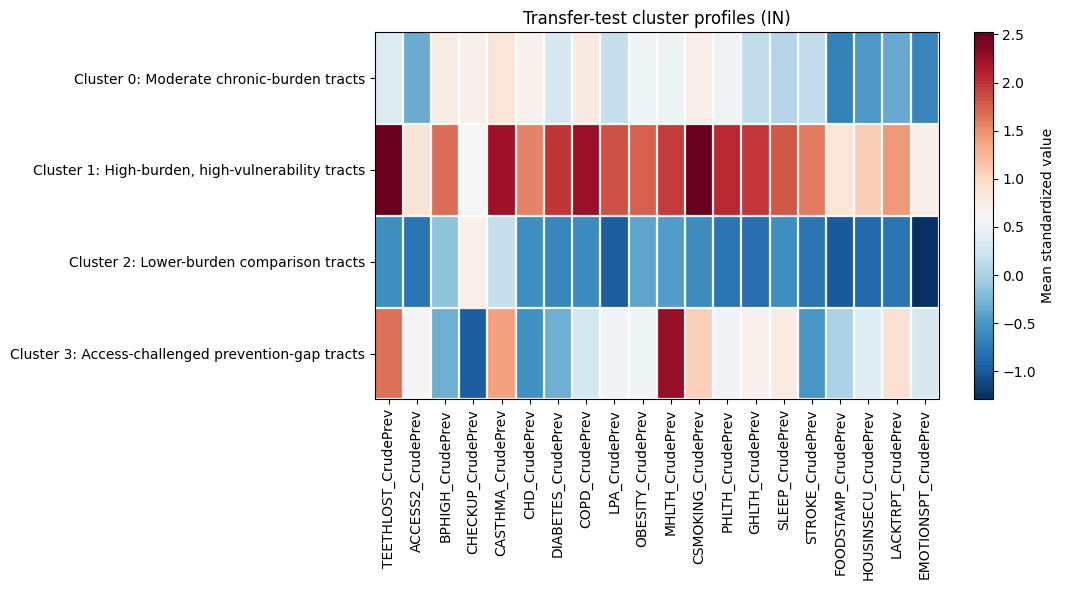

In [74]:
# Apply the final Illinois-trained pipeline and model to a second state
TRANSFER_STATE_VALUE = "IN"

# Filter the original dataframe for the transfer state and check that it contains data and the required features before applying the same imputation, scaling, and PCA transformations as were used for the original state, and then use the final K-means model to predict cluster labels for the transfer state, which will allow us to evaluate how well the clustering solution generalizes to a different context and whether the same segments can be identified in another state with similar characteristics.
df_transfer = df_raw[df_raw[STATE_COLUMN] == TRANSFER_STATE_VALUE].copy()

# Check that the transfer state dataframe is not empty and contains all the required features before proceeding with the imputation, scaling, and prediction steps. If there are issues with the transfer state data, such as missing rows or missing features, raise an error to alert the user and prevent misleading results from being generated.
if df_transfer.empty:
    raise ValueError(f"No rows were found for state {TRANSFER_STATE_VALUE}.")

# Check for missing features in the transfer state dataframe before applying the imputation, scaling, and PCA transformations. If any required features are missing, raise an error to alert the user and prevent misleading results from being generated due to incomplete data in the transfer state.
missing_transfer_features = [col for col in feature_cols_final if col not in df_transfer.columns]
if missing_transfer_features:
    raise ValueError(f"The transfer state is missing required features: {missing_transfer_features}")

# Apply the same imputation, scaling, and PCA transformations to the transfer state data as were applied to the original state data, using the fitted imputer, scaler, and PCA from the original state to ensure that the transfer state data is processed in the same way and can be meaningfully compared to the original state clusters when we predict cluster labels for the transfer state using the final K-means model.
X_transfer = df_transfer[feature_cols_final].copy()
X_transfer_imputed = imputer.transform(X_transfer)
X_transfer_scaled = scaler_used.transform(X_transfer_imputed)
X_transfer_scaled_df = pd.DataFrame(X_transfer_scaled, columns=feature_cols_final, index=df_transfer.index)
X_transfer_cluster = pca.transform(X_transfer_scaled) if USE_PCA else X_transfer_scaled

# Use the final K-means model trained on the original state to predict cluster labels for the transfer state data that has been processed with the same imputation, scaling, and PCA transformations, so that we can evaluate how well the clustering solution generalizes to a different state and whether the same clusters are identifiable in the new context.
transfer_labels = final_kmeans_model.predict(X_transfer_cluster)
df_transfer_model = df_transfer.copy()
df_transfer_model["cluster"] = transfer_labels

# Evaluate the clustering results for the transfer state using the same evaluation function as before, and display the results in a table format to provide insight into how well the original K-means model generalizes to the transfer state and whether the clusters identified in the original state are meaningful in the new context, which can inform interpretation and recommendations for stakeholders in the transfer state.
transfer_result = evaluate_clustering(
    X_transfer_cluster,
    transfer_labels,
    algorithm_name=f"KMeans transfer from {STATE_VALUE} to {TRANSFER_STATE_VALUE}"
)
transfer_result.update({"params": f"trained_on={STATE_VALUE}, predicted_on={TRANSFER_STATE_VALUE}"})

# Display the transfer test evaluation results in a table format to summarize how well the original K-means model performs when applied to the transfer state data.
show_table(pd.DataFrame([result_to_row(transfer_result)]), "transfer_test_summary", index=False)

# Create a table showing the size of each cluster in the transfer state to provide insight into the distribution of observations across the clusters in the new context, which can inform interpretation and stakeholder recommendations based on the relative sizes of each segment identified by the model in the transfer state.
transfer_counts = pd.Series(transfer_labels).value_counts().sort_index().rename("tract_count")
show_table(transfer_counts.to_frame(), "transfer_test_cluster_counts", index=True)

# Create a table comparing the relative share of each cluster between the original state and the transfer state to provide insight into how the distribution of observations across clusters changes when the model is applied to the new state, which can help stakeholders understand whether the segments identified in the original state are similarly represented in the transfer state.
cluster_share_compare = pd.DataFrame({
    f"{STATE_VALUE}_share": (cluster_counts / cluster_counts.sum()).reindex(sorted(cluster_counts.index)),
    f"{TRANSFER_STATE_VALUE}_share": (transfer_counts / transfer_counts.sum()).reindex(sorted(cluster_counts.index), fill_value=0)
}).reset_index().rename(columns={"index": "cluster"})
show_table(cluster_share_compare, "transfer_test_cluster_share_comparison", index=False)

# Create a table showing the mean standardized feature values for each cluster in the transfer state to provide insight into the profiles of each cluster in the new context, which can inform interpretation and stakeholder recommendations based on the characteristics of each segment identified by the model in the transfer state.
transfer_profile = X_transfer_scaled_df.copy()
transfer_profile["cluster"] = transfer_labels
transfer_cluster_means = transfer_profile.groupby("cluster")[feature_cols_final].mean()
show_table(transfer_cluster_means.round(2), "transfer_test_cluster_profiles_standardized", index=True)

# Calculate the correlation between the cluster profiles in the original state and the transfer state for the shared clusters to evaluate how similar the cluster profiles are between the two states, which can provide insight into whether the same segments identified in the original state have similar characteristics in the transfer state, informing interpretation and recommendations for stakeholders in the new context.
shared_clusters = sorted(set(cluster_means.index).intersection(set(transfer_cluster_means.index)))
profile_similarity_rows = []
for cluster_id in shared_clusters:
    similarity = np.corrcoef(cluster_means.loc[cluster_id], transfer_cluster_means.loc[cluster_id])[0, 1]
    profile_similarity_rows.append({"cluster": cluster_id, "profile_correlation": similarity})

# Create a DataFrame from the profile similarity rows and display it in a table format to summarize the correlation between the cluster profiles in the original state and the transfer state for the shared clusters, which can help stakeholders understand how well the characteristics of each segment are preserved when the model is applied to a different context.
profile_similarity_df = pd.DataFrame(profile_similarity_rows)
show_table(profile_similarity_df, "transfer_test_profile_similarity", index=False)

# Visualize the transfer state clusters in the same 2D PCA space as the original state by applying the same PCA transformation to the transfer state data and creating a scatter plot with cluster labels annotated at the centroids, which can provide a visual comparison of how the clusters in the transfer state relate to those in the original state and whether they occupy similar regions in the reduced-dimensional space, informing interpretation and stakeholder recommendations based on the visual similarity of the clusters between the two states.
X_transfer_2d = viz_pca.transform(X_transfer_scaled)

# Create a scatter plot of the transfer state clusters in the PCA space, coloring points by their predicted cluster labels and annotating each cluster with its ID at the centroid, using the same styling as the original PCA scatter plot to maintain visual consistency and allow for easy comparison between the two states.
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_transfer_2d[:, 0], X_transfer_2d[:, 1], c=transfer_labels, s=14)

# Match the earlier cluster-label style: centered white text in a blue rounded box.
for cluster_id in np.unique(transfer_labels):
    mask = transfer_labels == cluster_id
    cx, cy = X_transfer_2d[mask, 0].mean(), X_transfer_2d[mask, 1].mean()
    ax.annotate(
        f"Cluster {cluster_id}",
        xy=(cx, cy),
        fontsize=10,
        fontweight="bold",
        color="white",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.7", fc="#1f77b4", ec="white", lw=2, alpha=0.95),
    )

# Set the same axis labels and title format as the original PCA scatter plot for consistency, and save the figure with a descriptive name that indicates it is the transfer test PCA scatter plot for the transfer state, which will help stakeholders understand that this visualization shows how the clusters in the transfer state relate to those in the original state in the PCA space.
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Transfer test in PCA space ({TRANSFER_STATE_VALUE})")
plt.tight_layout()
save_fig("transfer_test_pca_scatter")
plt.show()

# Create a heatmap of the mean standardized feature values for each cluster in the transfer state, using the same styling as the original cluster profile heatmap to maintain visual consistency and allow for easy comparison between the two states, which can provide insight into how the characteristics of each cluster in the transfer state compare to those in the original state based on their standardized feature profiles.
plt.figure(figsize=(max(10, len(feature_cols_final) * 0.55), 6))
im = plt.imshow(transfer_cluster_means.values, aspect="auto", cmap="RdBu_r")
plt.colorbar(im, label="Mean standardized value")
plt.xticks(range(len(feature_cols_final)), feature_cols_final, rotation=90)

# Create y-axis labels that include both the cluster ID and the descriptive label from the label_map if available, to provide more interpretable labels for each cluster in the heatmap that can help stakeholders understand the characteristics of each segment based on the descriptive labels while still showing the cluster IDs for reference.
transfer_row_labels = []
for cluster_id in transfer_cluster_means.index:
    if "label_map" in globals() and cluster_id in label_map:
        transfer_row_labels.append(f"Cluster {cluster_id}: {label_map[cluster_id]}")
    else:
        transfer_row_labels.append(f"Cluster {cluster_id}")
plt.yticks(range(len(transfer_cluster_means.index)), transfer_row_labels)

# Add white borders around each matrix cell for readability, matching the earlier heatmap style.
for x in np.arange(0.5, len(feature_cols_final), 1):
    plt.axvline(x=x, color="white", linewidth=1.6, alpha=0.95)
for y in np.arange(0.5, len(transfer_cluster_means.index), 1):
    plt.axhline(y=y, color="white", linewidth=1.6, alpha=0.95)

# Set the title of the heatmap to indicate that it shows the cluster profiles for the transfer state, and save the figure with a descriptive name that indicates it is the transfer test cluster profiles heatmap for the transfer state, which will help stakeholders understand that this visualization shows the standardized feature profiles of each cluster in the transfer state for comparison with the original state.
plt.title(f"Transfer-test cluster profiles ({TRANSFER_STATE_VALUE})")
plt.tight_layout()
save_fig("transfer_test_cluster_profiles_heatmap")
plt.show()


**🕵️‍♂️ Interpretation:**  

- The transfer test shows that the Illinois-trained workflow can be applied to **Indiana** without failing, and it still produces a four-cluster solution with a reasonable silhouette score (0.347). This means the model is capturing some broad tract-level health patterns that are not unique to Illinois.  
- At the same time, the Indiana cluster sizes are less balanced than the Illinois result. In Indiana, Cluster 0 contains about 66.5% of tracts, while the other three clusters are much smaller. This suggests that the same model structure carries over only partially.  
- The standardized profiles show that the transferred clusters still separate lower-burden tracts, higher-burden tracts, and access-related vulnerability patterns, but the share of tracts in each group changes across states. In particular, Indiana has a much larger share in Cluster 0 and a smaller share in Clusters 2 and 3 than Illinois.  
- The profile-similarity results support a **mixed** conclusion. One transferred cluster is very similar to its Illinois counterpart (correlation ≈ 0.88), while the others show only moderate or weaker similarity (about 0.31 to 0.59). This means some profiles transfer well, but not all of them reproduce in the same way.  

Overall, this section provides supportive but not conclusive evidence of portability. 

The final Illinois-trained model appears to capture a broader health-burden structure that can also be seen in another state, but the exact cluster balance and profile detail change. For the capstone, this supports a careful conclusion: the workflow has potential to be reused in other states, but it should be re-fitted and rechecked locally rather than assumed to transfer perfectly.